In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
import numpy as np
import gzip
import upsetplot

In [ ]:

poly_homopolymer_regions = [309,310,311,16179,16180,16181,16182,16183]
excluded_samples = ['ST002-1D_LUNG-pacbio-uwsc-group1']


In [ ]:

df_pb = pd.read_csv("/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/pacbio/output/qc_summary.tsv", sep='\t')
df_pb[['Donor', 'Tissue', 'Seq_Tech', 'Center', 'Group']] = df_pb['Sample'].str.split('-', expand=True)
#df_pb = df_pb.sort_values(['Donor', 'Tissue', 'Center'])
df_pb['Age'] = np.where(df_pb['Donor'].isin(['ST001', 'ST003']), 'Young', 'Old')

df_ont = pd.read_csv("/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/ont/output/qc_summary.tsv", sep='\t')
df_ont[['Donor', 'Tissue', 'Seq_Tech', 'Center']] = df_ont['Sample'].str.split('-', expand=True)
#df_ont = df_ont.sort_values(['Donor', 'Tissue', 'Center'])
df_ont['Age'] = np.where(df_ont['Donor'].isin(['ST001', 'ST003']), 'Young', 'Old')

df = pd.concat([df_pb, df_ont]).reset_index()
df['Donor_Tissue'] = df['Donor'] + "-" + df['Tissue']
df = df.sort_values(['Tissue', 'Donor', 'Center'])

df = df[~(df['Sample'].isin(excluded_samples))]

df['mtDNA_CN'] = (df['Mito_Coverage'] / df['Nuclear_Coverage']) * 2
df['Tissue'] = df['Tissue'].str.split('_', expand=True)[1].str.capitalize()

df['Seq_Tech'] = np.where(df['Seq_Tech'] == 'pacbio', 'PacBio', 'ONT')

df

,index,Sample,Total_Read_Count,ChrM_Read_Count,Kmer_Read_Count,Mito_Read_Count,mtDNA_CN,Mean_Read_Length,Median_Read_Length,Mito_Coverage,Nuclear_Coverage,Haplogroup,Donor,Tissue,Seq_Tech,Center,Group,Age,Donor_Tissue
11,11,ST001-1A_LIVER-pacbio-bcm,14733673,14030,13923,13882,326.509066,14196.79,14864.0,11884.93,72.80,H3b1b1,ST001,Liver,PacBio,bcm,None,Young,ST001-1A_LIVER
39,17,ST001-1A_LIVER-ont-bcm,21967786,87222,58490,54220,836.184949,10104.80,9916.0,32778.45,78.40,H3b1b1,ST001,Liver,ONT,bcm,NaN,Young,ST001-1A_LIVER
14,14,ST001-1A_LIVER-pacbio-broad,12125667,26272,26232,26117,667.146738,12629.30,12192.0,19890.98,59.63,H3b1b1,ST001,Liver,PacBio,broad,None,Young,ST001-1A_LIVER
36,14,ST001-1A_LIVER-ont-nygc,30322189,135334,45322,41247,401.898603,6593.18,5459.0,16250.77,80.87,H3b1b1,ST001,Liver,ONT,nygc,NaN,Young,ST001-1A_LIVER
15,15,ST001-1A_LIVER-pacbio-uwsc,4226911,15242,15188,15134,1087.289805,15604.38,16404.0,14238.06,26.19,H3b1b1,ST001,Liver,PacBio,uwsc,None,Young,ST001-1A_LIVER
38,16,ST001-1A_LIVER-ont-uwsc,78669019,579591,68136,48938,897.824434,6802.95,5441.0,19841.92,44.20,H3b1b1,ST001,Liver,ONT,uwsc,NaN,Young,ST001-1A_LIVER
16,16,ST001-1A_LIVER-pacbio-washu,11826270,19010,18961,18660,491.957475,16242.37,16555.0,18278.68,74.31,H3b1b1,ST001,Liver,PacBio,washu,None,Young,ST001-1A_LIVER
1,1,ST001-1D_LUNG-pacbio-bcm,19895520,1248,1236,1232,21.703931,14310.17,14880.5,1062.95,97.95,H3b1b1,ST001,Lung,PacBio,bcm,None,Young,ST001-1D_LUNG
25,3,ST001-1D_LUNG-ont-bcm,19937801,3449,2458,2265,33.808773,10924.42,10830.0,1479.81,87.54,H3b1b1,ST001,Lung,ONT,bcm,NaN,Young,ST001-1D_LUNG
6,6,ST001-1D_LUNG-pacbio-broad,15307052,1637,1636,1622,30.943342,13317.68,13431.5,1302.56,84.19,H3b1b1,ST001,Lung,PacBio,broad,None,Young,ST001-1D_LUNG


['\n\n1A_LIVER', '\n\n1D_LUNG', '\n\n1D_LUNG', '\n\n1G_COLON', '\n\n1Q_BRAIN', '\n\n1Q_BRAIN']


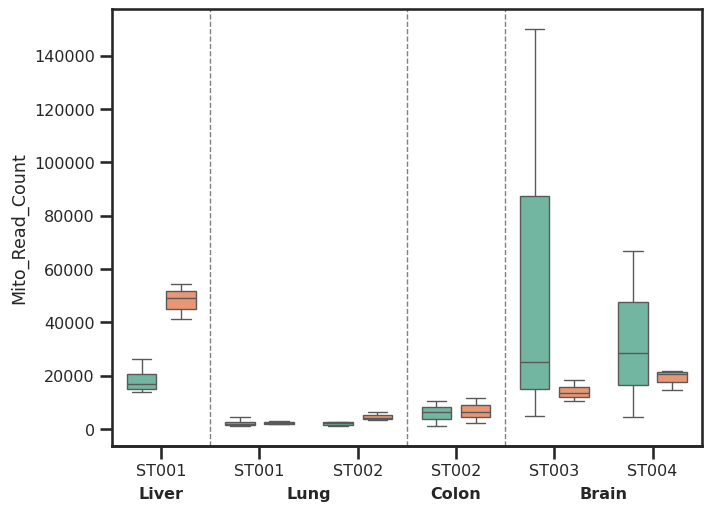

['\n\n1A_LIVER', '\n\n1D_LUNG', '\n\n1D_LUNG', '\n\n1G_COLON', '\n\n1Q_BRAIN', '\n\n1Q_BRAIN']


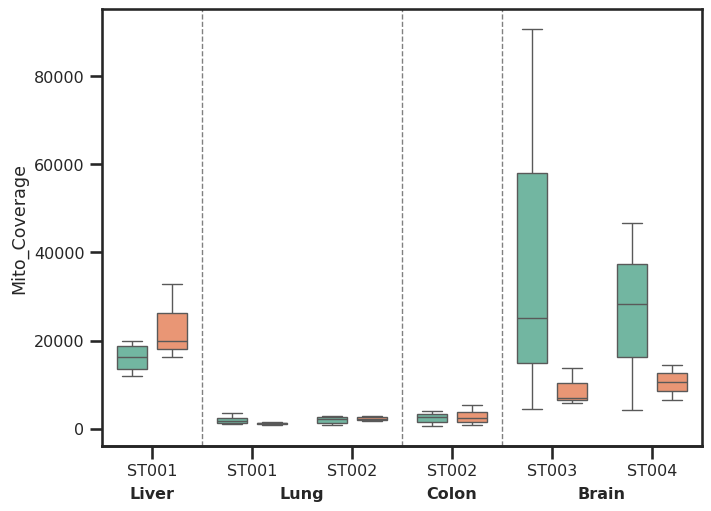

['\n\n1A_LIVER', '\n\n1D_LUNG', '\n\n1D_LUNG', '\n\n1G_COLON', '\n\n1Q_BRAIN', '\n\n1Q_BRAIN']


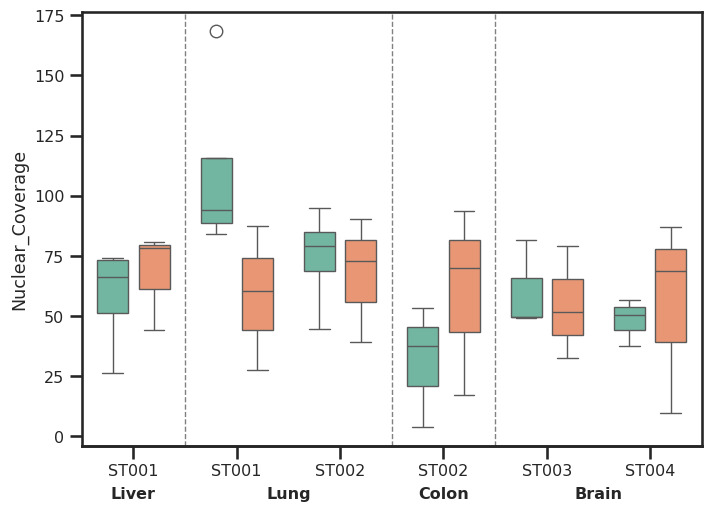

['\n\n1A_LIVER', '\n\n1D_LUNG', '\n\n1D_LUNG', '\n\n1G_COLON', '\n\n1Q_BRAIN', '\n\n1Q_BRAIN']


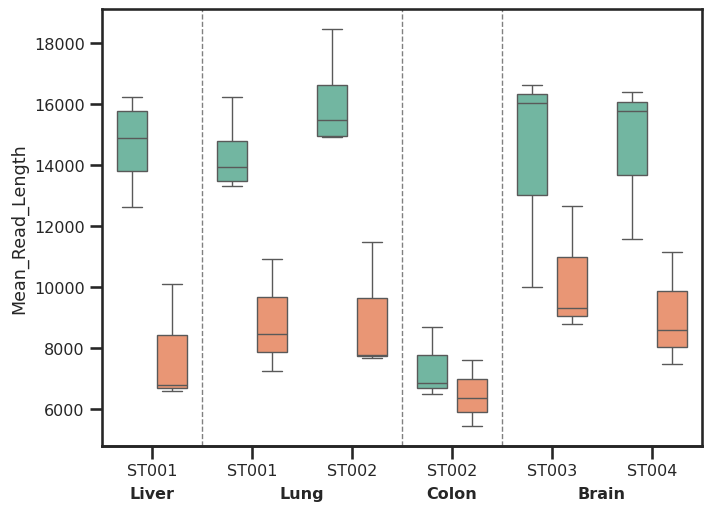

In [ ]:
sns.set_theme(style="ticks", context="talk", font_scale=0.7)

for category in ["Mito_Read_Count", "Mito_Coverage", "Nuclear_Coverage", "Mean_Read_Length"]:

    fig, ax = plt.subplots(layout='constrained', figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="Donor_Tissue",
        y=category,
        hue="Seq_Tech",
        showfliers=True,
        palette="Set2",
        widths=0.3,
        legend=False,
        ax=ax
    )

    # Get original tick labels
    ticks = ax.get_xticklabels()
    labels = [t.get_text() for t in ticks]
    donors  = [l.split("-")[0] for l in labels]  
    tissues = ['\n\n' + l.split("-")[1] for l in labels]

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(donors, rotation=0)
    ax.set_ylabel(category)
    ax.set_xlabel("")

    sec = ax.secondary_xaxis(location=0)
    sec.set_xticks([0,1.5,3,4.5], labels=['\n\nLiver', '\n\nLung', '\n\nColon', '\n\nBrain'])
    sec.tick_params('x', length=0)

    for tick in sec.get_xticklabels():
        tick.set_fontweight("bold")
        #tick.set_fontsize(14)

    midpoints = [0.5,2.5,3.5]
    for x in midpoints:
        ax.axvline(x=x,color="gray",linestyle="--",linewidth=1,alpha=1,zorder=0)

    #plt.yscale('log')
    print(tissues)
    plt.savefig(f"plots/fig3-benchmark_tissue_QC_{category}.pdf", dpi=300)
    plt.show()

['\n\nLIVER', '\n\nLUNG', '\n\nLUNG', '\n\nCOLON', '\n\nBRAIN', '\n\nBRAIN']
['ST001', 'ST001', 'ST002', 'ST002', 'ST003', 'ST004']


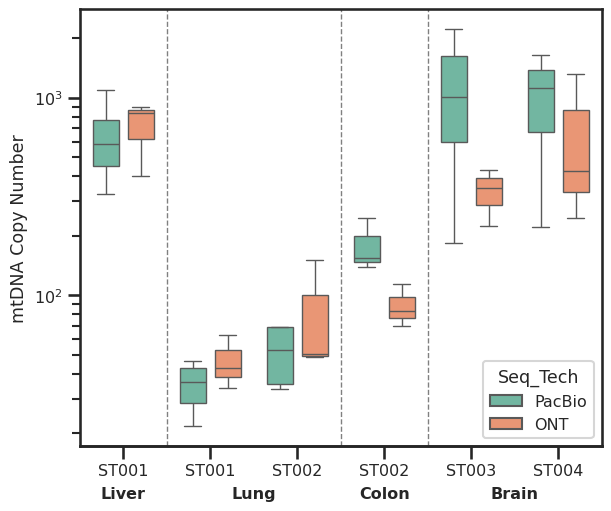

In [ ]:
sns.set_theme(style="ticks", context="talk", font_scale=0.7)

for category in ["mtDNA_CN"]:

    fig, ax = plt.subplots(layout='constrained', figsize=(6, 5))

    sns.boxplot(
        data=df,
        x="Donor_Tissue",
        y=category,
        hue="Seq_Tech",
        showfliers=True,
        palette="Set2",
        widths=0.3,
        legend=True,
        ax=ax
    )

    # Get original tick labels
    ticks = ax.get_xticklabels()
    labels = [t.get_text() for t in ticks]
    donors  = [l.split("-")[0] for l in labels]  
    tissues = ['\n\n' + l.split("-")[1].split("_")[1] for l in labels]

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(donors, rotation=0)
    ax.set_ylabel("mtDNA Copy Number")
    ax.set_xlabel("")

    sec = ax.secondary_xaxis(location=0)
    sec.set_xticks([0,1.5,3,4.5], labels=['\n\nLiver', '\n\nLung', '\n\nColon', '\n\nBrain'])
    sec.tick_params('x', length=0)

    for tick in sec.get_xticklabels():
        tick.set_fontweight("bold")
        #tick.set_fontsize(14)

    midpoints = [0.5,2.5,3.5]
    for x in midpoints:
        ax.axvline(x=x,color="gray",linestyle="--",linewidth=1,alpha=1,zorder=0)

    plt.yscale('log')
    print(tissues)
    print(donors)
    plt.savefig(f"plots/fig3-benchmark_tissue_QC_{category}.pdf", dpi=300)
    plt.show()

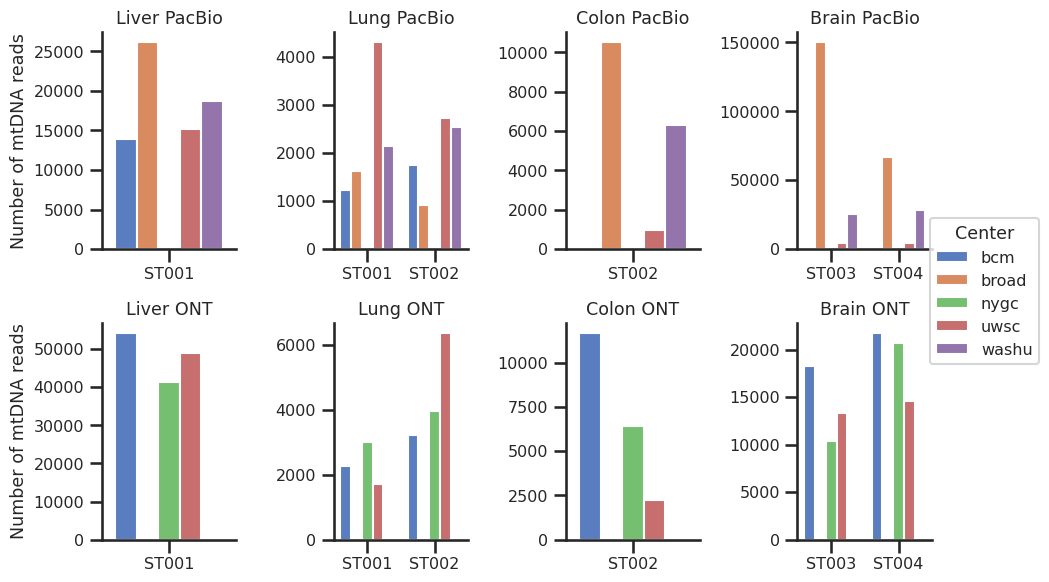

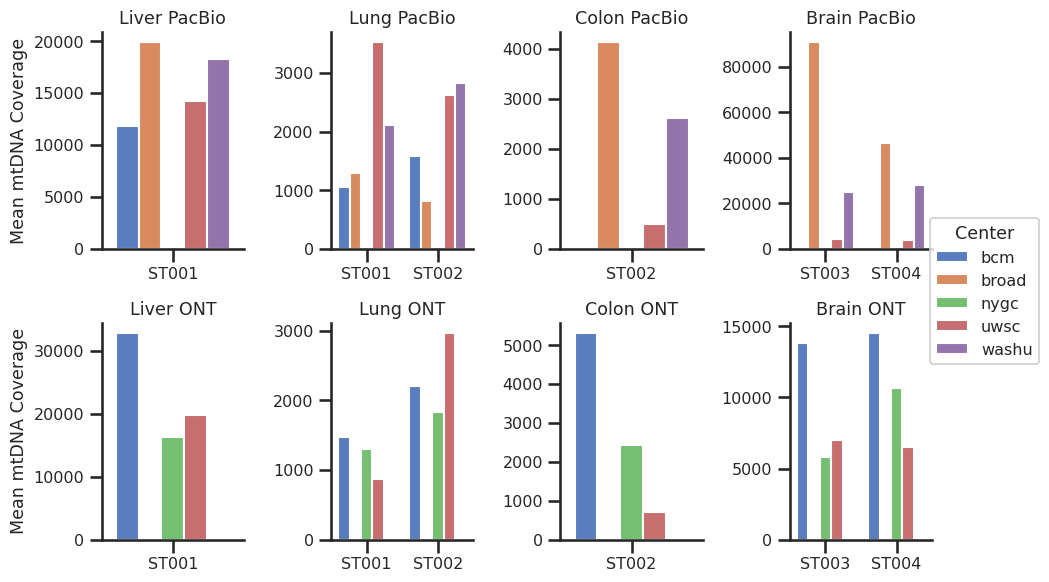

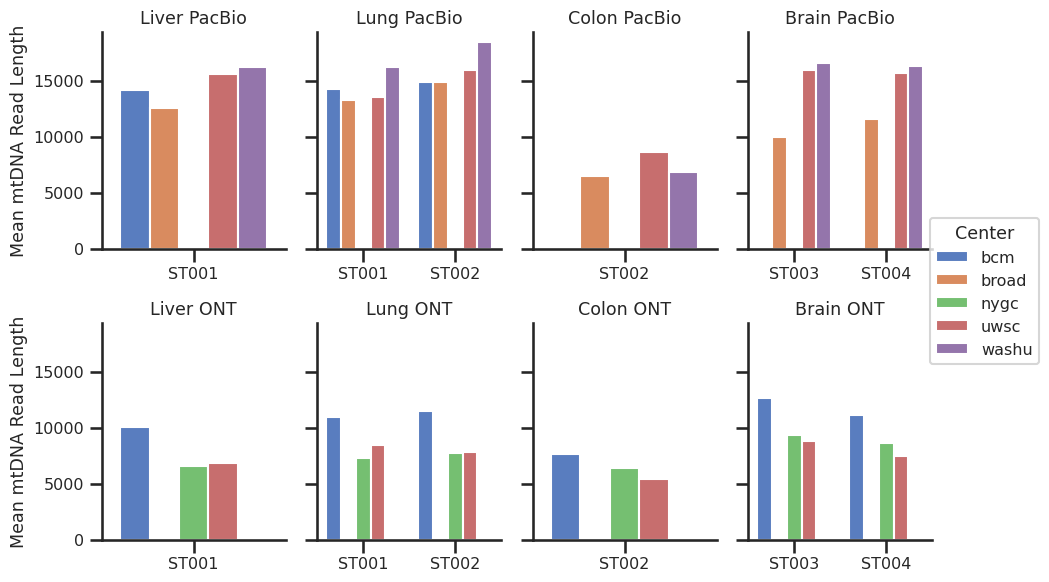

In [ ]:
g = sns.catplot(
    data=df,
    x="Donor",
    y="Mito_Read_Count",
    col="Tissue",
    row="Seq_Tech",
    hue="Center",
    kind="bar",
    height=3,
    aspect=0.8,
    palette="muted",
    legend_out=False,
    sharex=False,
    sharey=False
)
sns.move_legend(g, "center right", bbox_to_anchor=(1.1,0.5)) 
g.set_titles("{col_name} {row_name}")
g.set_axis_labels("", "Number of mtDNA reads")
plt.tight_layout()
plt.show()

g = sns.catplot(
    data=df,
    x="Donor",
    y="Mito_Coverage",
    col="Tissue",
    row="Seq_Tech",
    hue="Center",
    kind="bar",
    height=3,
    aspect=0.8,
    palette="muted",
    legend_out=False,
    sharex=False,
    sharey=False
)
sns.move_legend(g, "center right", bbox_to_anchor=(1.1,0.5)) 
g.set_titles("{col_name} {row_name}")
g.set_axis_labels("", "Mean mtDNA Coverage")
plt.tight_layout()
plt.show()

g = sns.catplot(
    data=df,
    x="Donor",
    y="Mean_Read_Length",
    col="Tissue",
    row="Seq_Tech",
    hue="Center",
    kind="bar",
    height=3,
    aspect=0.8,
    palette="muted",
    legend_out=False,
    sharex=False,
    sharey=True
)
sns.move_legend(g, "center right", bbox_to_anchor=(1.1,0.5)) 
g.set_titles("{col_name} {row_name}")
g.set_axis_labels("", "Mean mtDNA Read Length")
plt.tight_layout()
plt.show()


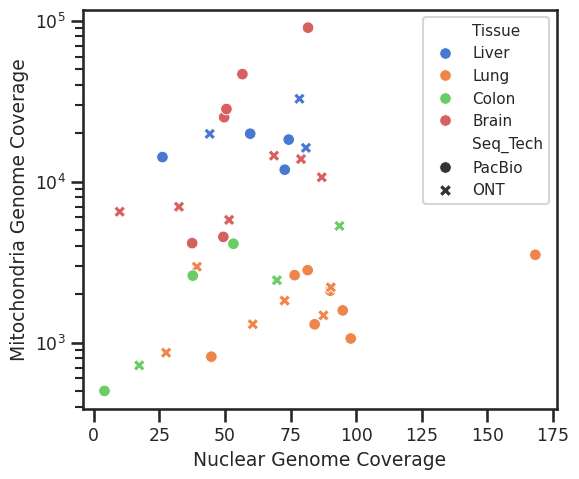

In [ ]:
## mt coverage vs nuc coverage (pull from qc) - see tissue differences
sns.set_theme(style="ticks", context="talk", font_scale=0.75)

plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x="Nuclear_Coverage",
    y="Mito_Coverage",
    hue="Tissue",     
    palette="muted",
    s=70,
    style="Seq_Tech",
  # size="Nuclear_Coverage",      # optional: also scale by size
  #  sizes=(40, 200),
    alpha=1)
plt.xlabel("Nuclear Genome Coverage")
plt.ylabel("Mitochondria Genome Coverage")
plt.yscale("log")
#plt.xscale("log")
plt.title("")
plt.legend(title="", loc='upper right', fontsize=11)
plt.tight_layout()
plt.savefig("plots/fig3-benchmark_tissue_coverage.pdf", dpi=300)
plt.show()



In [ ]:
def read_vcf(input_file):
    with gzip.open(input_file, 'rt') as fr:
        for line in fr:
            if line.startswith('#CHROM'):
                header = line.strip().lstrip('#').split('\t')
                break

    df = pd.read_csv(input_file, comment='#', sep='\t', compression='gzip', names=header)
    return df

snv_vcf_pb = read_vcf("/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/pacbio/output/merged.mt.baldur.annotated.vcf.gz")
snv_vcf_ont = read_vcf("/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/ont/output/merged.mt.baldur.annotated.vcf.gz")

snv_vcf_pb['ID'] = snv_vcf_pb[['CHROM', 'POS', 'REF', 'ALT']].astype(str).agg('-'.join, axis=1)
snv_vcf_ont['ID'] = snv_vcf_ont[['CHROM', 'POS', 'REF', 'ALT']].astype(str).agg('-'.join, axis=1)

filter_col = [col for col in snv_vcf_pb if col.startswith('ST00')]
snv_df_pb = pd.melt(
    snv_vcf_pb[["POS", "ID", "INFO"] + filter_col],
    id_vars=['POS', 'ID', "INFO"],
    var_name='Sample',
    value_name='Value'
)

filter_col = [col for col in snv_vcf_ont if col.startswith('ST00')]
snv_df_ont = pd.melt(
    snv_vcf_ont[["POS", "ID", "INFO"] + filter_col],
    id_vars=['POS', 'ID', "INFO"],
    var_name='Sample',
    value_name='Value'
)

snv_df = pd.concat([snv_df_pb, snv_df_ont])

snv_df[['Donor', 'Tissue', 'Seq_Tech', 'Center', 'Group']] = snv_df['Sample'].str.split('-', expand=True)
snv_df['Tissue'] = snv_df['Tissue'].str.split("_", expand=True)[1].str.capitalize()
snv_df['Donor_Tissue'] = snv_df['Donor'] + "_" + snv_df['Tissue']

snv_df['VEP'] = snv_df['INFO'].str.extract(r'CSQ=(.+);')
snv_df[['Consequence', 'Impact', 'Symbol', 'Biotype']] = snv_df['VEP'].str.split('|', expand=True)[[1,2,3,7]]

snv_df['MITOMAP'] = snv_df['INFO'].str.extract(r'MITOMAP=(.+);')
snv_df[['Gene.Name', 'Gene.Type', 'Amino.Acid.Change', 'GB.Freq.FL', 'GB.Freq.CR', 'GB.Seqs.FL', 'GB.Seqs.CR', 'Disease', 'Status', 'Additional.Annotations', 'MitoTIP']] = snv_df['MITOMAP'].str.split('|', expand=True)[[0,1,2,3,4,5,6,9,10,12,13]]

snv_df = snv_df[~(snv_df['Sample'].isin(excluded_samples))]
snv_df = snv_df[~(snv_df['POS'].isin(poly_homopolymer_regions))]

snv_df


,POS,ID,INFO,Sample,Value,Donor,Tissue,Seq_Tech,Center,Group,...,Gene.Type,Amino.Acid.Change,GB.Freq.FL,GB.Freq.CR,GB.Seqs.FL,GB.Seqs.CR,Disease,Status,Additional.Annotations,MitoTIP
0,64,MT-64-C-T,CSQ=T|intergenic_variant|MODIFIER|||||||||||||...,ST001-1A_LIVER-pacbio-bcm,"././.:.:.:.:.:.:.,.:.:.:.",ST001,Liver,pacbio,bcm,None,...,control region,noncoding,2.963%,2.549%,1811.0,2050.0,,,MT-HV2,
1,64,MT-64-C-A,CSQ=A|intergenic_variant|MODIFIER|||||||||||||...,ST001-1A_LIVER-pacbio-bcm,"././.:.:.:.:.:.:.,.:.:.:.",ST001,Liver,pacbio,bcm,None,...,control region,noncoding,0.010%,0.006%,6.0,5.0,,,MT-HV2,
2,65,MT-65-TG-T,CSQ=-|intergenic_variant|MODIFIER|||||||||||||...,ST001-1A_LIVER-pacbio-bcm,"././.:.:.:.:.:.:.,.:.:.:.",ST001,Liver,pacbio,bcm,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,66,MT-66-G-A,CSQ=A|intergenic_variant|MODIFIER|||||||||||||...,ST001-1A_LIVER-pacbio-bcm,"0/1:1305,16:8499,46:0.00527:0.0019,0.00078:40,...",ST001,Liver,pacbio,bcm,None,...,control region,noncoding,0.095%,0.087%,58.0,70.0,,,MT-HV2,
4,66,MT-66-G-T,CSQ=T|intergenic_variant|MODIFIER|||||||||||||...,ST001-1A_LIVER-pacbio-bcm,"././.:.:.:.:.:.:.,.:.:.:.",ST001,Liver,pacbio,bcm,None,...,control region,noncoding,0.101%,0.045%,62.0,36.0,,,MT-HV2,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2479,16278,MT-16278-C-T,CSQ=T|intergenic_variant|MODIFIER|||||||||||||...,ST004-1Q_BRAIN-ont-uwsc,"1:1,1194:0,1154:1:0,0.00109:0,40:q30;low_freq,...",ST004,Brain,ont,uwsc,None,...,control region,noncoding,9.814%,9.286%,5999.0,7469.0,,,MT-HV1,
2480,16304,MT-16304-T-C,CSQ=C|intergenic_variant|MODIFIER|||||||||||||...,ST004-1Q_BRAIN-ont-uwsc,"./.:.:.:.:.:.:.,.:.:.:.",ST004,Brain,ont,uwsc,None,...,control region,noncoding,7.516%,10.073%,4594.0,8102.0,,,MT-HV1,
2481,16311,MT-16311-T-C,CSQ=C|intergenic_variant|MODIFIER|||||||||||||...,ST004-1Q_BRAIN-ont-uwsc,"./.:.:.:.:.:.:.,.:.:.:.",ST004,Brain,ont,uwsc,None,...,control region,noncoding,19.146%,17.468%,11703.0,14050.0,,,MT-HV1,
2482,16390,MT-16390-G-A,CSQ=A|intergenic_variant|MODIFIER|||||||||||||...,ST004-1Q_BRAIN-ont-uwsc,"./.:.:.:.:.:.:.,.:.:.:.",ST004,Brain,ont,uwsc,None,...,control region,noncoding,5.394%,5.826%,3297.0,4686.0,POAG - potential for association,Reported,,


In [ ]:
snv_df[['GT', 'ADF', 'ADR','HPL', 'FQSE', 'AQ', 'AFLT', 'QAVG', 'FSB', 'QBS']] = snv_df['Value'].str.split(':', expand=True)
#snv_df[['CHROM', 'POS', 'REF', 'ALT']] = snv_df['ID'].str.split('-', expand=True)
snv_df = snv_df.drop(columns=['Value', 'INFO'])
snv_df = snv_df[(snv_df['GT'] != '.') & (snv_df['GT'] != './.') & (snv_df['GT'] != '././.') & (snv_df['GT'] != './././.') & (snv_df['GT'] != '././././.')]
snv_df['AF'] = snv_df['HPL']

### note - this doesn't seem to be necessary for baldur, bcftools norm takes care as expected ###
def extract_element(row):
    if ',' in row['AF']:
        parts = row['AF'].split(',')
        if row['GT'] == '0/1':
            return parts[1]
        elif row['GT'] == '1/0':
            return parts[0]
    return row['AF']

snv_df['AF'] = snv_df.apply(extract_element, axis=1)
snv_df['AF'] = snv_df['AF'].astype(float)

snv_df[['MT', 'POS', 'REF', 'ALT']] = snv_df['ID'].str.split('-', expand=True)
snv_df['indel'] = snv_df.apply(lambda row: 'indel' if (len(row['REF']) > 1 or len(row['ALT']) > 1) else 'snv', axis=1)

snv_df

,POS,ID,Sample,Donor,Tissue,Seq_Tech,Center,Group,Donor_Tissue,VEP,...,AQ,AFLT,QAVG,FSB,QBS,AF,MT,REF,ALT,indel
3,66,MT-66-G-A,ST001-1A_LIVER-pacbio-bcm,ST001,Liver,pacbio,bcm,None,ST001_Liver,A|intergenic_variant|MODIFIER|||||||||||||||||...,...,"40,40","PASS,PASS","29.62,30","1,0.0065","1,0.997",0.00527,MT,G,A,snv
5,67,MT-67-G-A,ST001-1A_LIVER-pacbio-bcm,ST001,Liver,pacbio,bcm,None,ST001_Liver,A|intergenic_variant|MODIFIER|||||||||||||||||...,...,"40,40","PASS,PASS","29.96,29.85","1,0.0987","1,0.148",0.00362,MT,G,A,snv
6,72,MT-72-T-C,ST001-1A_LIVER-pacbio-bcm,ST001,Liver,pacbio,bcm,None,ST001_Liver,C|intergenic_variant|MODIFIER|||||||||||||||||...,...,"40,40","PASS,PASS","29.89,29.9","1,0.0536","1,5.26e-05",0.03249,MT,T,C,snv
8,76,MT-76-C-T,ST001-1A_LIVER-pacbio-bcm,ST001,Liver,pacbio,bcm,None,ST001_Liver,T|intergenic_variant|MODIFIER|||||||||||||||||...,...,"40,40","PASS,PASS","29.84,29.96","1,0.563","1,0.503",0.00498,MT,C,T,snv
11,153,MT-153-A-G,ST001-1A_LIVER-pacbio-bcm,ST001,Liver,pacbio,bcm,None,ST001_Liver,G|intergenic_variant|MODIFIER|||||||||||||||||...,...,"40,40","PASS,PASS","29.99,29.85","0.391,1","0.697,1",0.97993,MT,A,G,snv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2474,16189,MT-16189-T-C,ST004-1Q_BRAIN-ont-uwsc,ST004,Brain,ont,uwsc,None,ST004_Brain,C|intergenic_variant|MODIFIER|||||||||||||||||...,...,"0,40","q30;low_freq,PASS","23.83,26.28","0.021,1","0.00349,1",1.00000,MT,T,C,snv
2475,16223,MT-16223-C-T,ST004-1Q_BRAIN-ont-uwsc,ST004,Brain,ont,uwsc,None,ST004_Brain,T|intergenic_variant|MODIFIER|||||||||||||||||...,...,"3,40","q30;low_freq,PASS","24,24.28","0.00735,1","0.00919,1",0.99939,MT,C,T,snv
2477,16260,MT-16260-C-T,ST004-1Q_BRAIN-ont-uwsc,ST004,Brain,ont,uwsc,None,ST004_Brain,T|intergenic_variant|MODIFIER|||||||||||||||||...,...,"0,40","q30;low_freq,PASS","26.14,24.23","0.053,1","0.176,1",0.99999,MT,C,T,snv
2479,16278,MT-16278-C-T,ST004-1Q_BRAIN-ont-uwsc,ST004,Brain,ont,uwsc,None,ST004_Brain,T|intergenic_variant|MODIFIER|||||||||||||||||...,...,"0,40","q30;low_freq,PASS","30,24.15","1,1","0.999,1",1.00000,MT,C,T,snv


In [ ]:
high_conf_snv_df = snv_df.groupby(['ID','Donor', 'Tissue']).filter(lambda x: len(x) > 1)
high_conf_snv_df.sort_values('HPL')

low_conf_snv_df = snv_df.groupby(['ID','Donor', 'Tissue']).filter(lambda x: len(x) == 1)
low_conf_snv_df

,POS,ID,Sample,Donor,Tissue,Seq_Tech,Center,Group,Donor_Tissue,VEP,...,AQ,AFLT,QAVG,FSB,QBS,AF,MT,REF,ALT,indel
262,5149,MT-5149-C-A,ST001-1A_LIVER-pacbio-broad,ST001,Liver,pacbio,broad,None,ST001_Liver,A|missense_variant|MODERATE|MT-ND2|ENSG0000019...,...,"40,40","PASS,PASS","29.69,28.71","1,3.37e-05","1,1.31e-18",0.00278,MT,C,A,snv
263,5177,MT-5177-G-A,ST001-1A_LIVER-pacbio-broad,ST001,Liver,pacbio,broad,None,ST001_Liver,A|synonymous_variant|LOW|MT-ND2|ENSG0000019876...,...,"40,40","PASS,PASS","29.86,29.25","1,0.0631","1,1.87e-13",0.00275,MT,G,A,snv
429,3106,MT-3106-C-CT,ST001-1A_LIVER-pacbio-uwsc,ST001,Liver,pacbio,uwsc,None,ST001_Liver,T|non_coding_transcript_exon_variant|MODIFIER|...,...,"40,40","PASS,PASS","29.52,29.08","1,0.414","1,3.53e-05",0.00338,MT,C,CT,indel
430,3109,MT-3109-T-C,ST001-1A_LIVER-pacbio-uwsc,ST001,Liver,pacbio,uwsc,None,ST001_Liver,C|non_coding_transcript_exon_variant|MODIFIER|...,...,"40,40","PASS,PASS","29.67,29.44","1,0.33","1,0.000247",0.00298,MT,T,C,snv
439,3597,MT-3597-C-T,ST001-1A_LIVER-pacbio-uwsc,ST001,Liver,pacbio,uwsc,None,ST001_Liver,T|synonymous_variant|LOW|MT-ND1|ENSG0000019888...,...,"40,40","PASS,PASS","29.55,29.68","1,0.224","1,0.244",0.00465,MT,C,T,snv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2150,8285,MT-8285-C-T,ST004-1Q_BRAIN-ont-bcm,ST004,Brain,ont,bcm,None,ST004_Brain,T|intergenic_variant|MODIFIER|||||||||||||||||...,...,"40,40","PASS,PASS","27.97,27.55","1,4.58e-06","1,5.32e-07",0.00367,MT,C,T,snv
2372,460,MT-460-T-C,ST004-1Q_BRAIN-ont-uwsc,ST004,Brain,ont,uwsc,None,ST004_Brain,C|intergenic_variant|MODIFIER|||||||||||||||||...,...,"40,30","PASS,PASS","24.43,24.08","1,0.000488","1,3.9e-05",0.00358,MT,T,C,snv
2375,545,MT-545-G-A,ST004-1Q_BRAIN-ont-uwsc,ST004,Brain,ont,uwsc,None,ST004_Brain,A|intergenic_variant|MODIFIER|||||||||||||||||...,...,"40,40","PASS,PASS","24.55,24.19","1,1","1,0.000147",0.00759,MT,G,A,snv
2399,4440,MT-4440-G-A,ST004-1Q_BRAIN-ont-uwsc,ST004,Brain,ont,uwsc,None,ST004_Brain,A|non_coding_transcript_exon_variant|MODIFIER|...,...,"40,40","PASS,PASS","26.56,25.26","1,7.14e-05","1,2.48e-11",0.01331,MT,G,A,snv


In [ ]:
g = low_conf_snv_df[low_conf_snv_df['indel'] == 'indel'].sort_values('AF')
g['Center'].value_counts()
## ^ all low-confidence indels are from uwsc samples

gg = low_conf_snv_df[low_conf_snv_df['indel'] == 'snv']
gg['Center'].value_counts()
## ^ and most low-confidence snvs as well


Center
uwsc     65
bcm      17
broad     9
washu     6
nygc      4
Name: count, dtype: int64

In [ ]:
collapsed_by_center = snv_df.groupby(['ID','Donor', 'Tissue', 'indel']).agg(reps=('ID', 'count'), AF=('AF', 'mean')).reset_index()
collapsed_by_center['heteroplasmy_category'] = np.where(collapsed_by_center['AF'] > 0.95, 'homo', 'hetero')

def count_equal_to_1(x):
    return (x == 1).sum()

def count_greater_than_1(x):
    return (x > 1).sum()

result = collapsed_by_center.groupby(['Donor', 'Tissue', 'heteroplasmy_category', 'indel'])['reps'].agg(
    lc=count_equal_to_1,
    hc=count_greater_than_1
).reset_index()

result

result['Donor_Tissue'] = result['Donor'] + "-" + result['Tissue']
result['hc_perc'] = result['hc'] / (result['lc'] + result['hc'])

result.groupby(['heteroplasmy_category', 'indel']).agg(m=('hc_perc', 'mean'), lc_count=('lc', 'sum'), hc_count=('hc', 'sum'))

#result


m  lc_count  hc_count
heteroplasmy_category indel                              
hetero                indel  0.037143        49         3
                      snv    0.340469       101        49
homo                  snv    1.000000         0       166

In [ ]:
collapsed_by_center['confidence'] = np.where(collapsed_by_center['reps'] > 1, 'high', 'low')
collapsed_by_center.to_csv('tables/benchmarking_variants_ALL.csv')

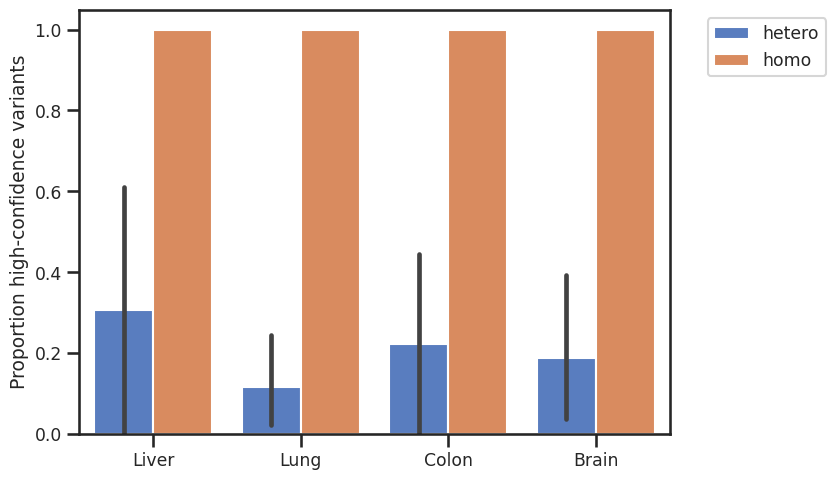

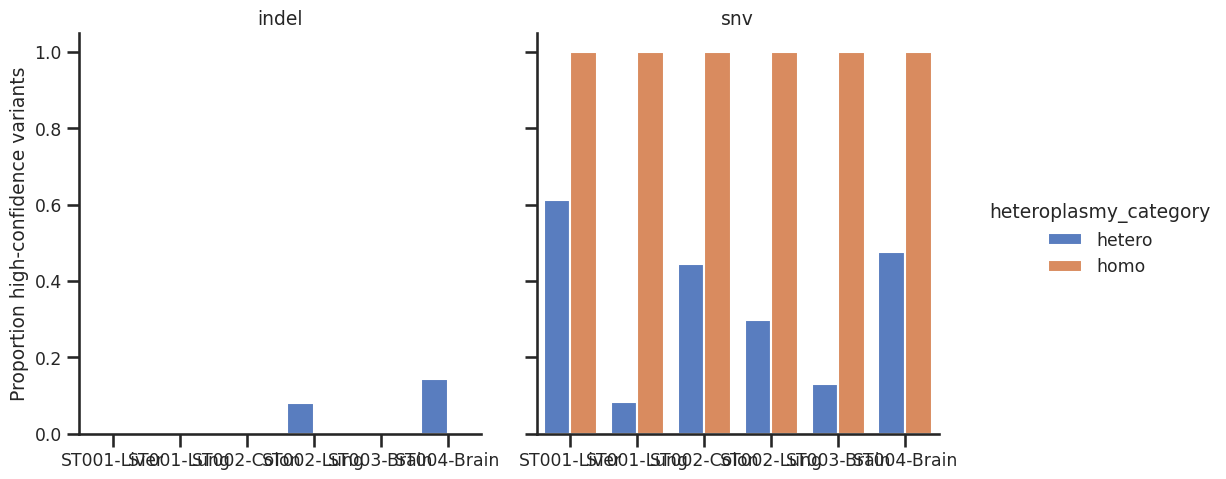

In [ ]:
sns.set_theme(style="ticks", context="talk", font_scale=0.75)

plt.figure(figsize=(7,5))
sns.barplot(
    data=result,
    x="Tissue",
    y="hc_perc",
    hue="heteroplasmy_category",     
    palette="muted")
plt.xlabel("")
plt.ylabel("Proportion high-confidence variants")
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.ylim(0,1)
plt.show()

sns.set_theme(style="ticks", context="talk", font_scale=0.75)

g = sns.catplot(
    data=result,
    x="Donor_Tissue",
    y="hc_perc",
    col="indel",
    hue="heteroplasmy_category",         
    kind="bar",
    palette="muted",
    height=5,
    aspect=1
)

g.set_axis_labels("", "Proportion high-confidence variants")
g.set_titles("{col_name}")
g.tight_layout()

plt.show()

In [ ]:
def custom_join(series):
    return ','.join(series.astype(str))

high_conf_snv_df.groupby(
    ['ID', 'Donor_Tissue']).agg(
        reps=('AF', 'count'), AF=('AF', 'mean'), rep_names=('Sample', custom_join)).reset_index()


,ID,Donor_Tissue,reps,AF,rep_names
0,MT-10398-A-G,ST003_Brain,6,0.997680,"ST003-1Q_BRAIN-pacbio-broad,ST003-1Q_BRAIN-pac..."
1,MT-10658-A-G,ST002_Colon,6,1.000000,"ST002-1G_COLON-pacbio-broad,ST002-1G_COLON-pac..."
2,MT-10658-A-G,ST002_Lung,7,0.999963,"ST002-1D_LUNG-pacbio-bcm,ST002-1D_LUNG-pacbio-..."
3,MT-10825-A-G,ST002_Colon,6,0.999365,"ST002-1G_COLON-pacbio-broad,ST002-1G_COLON-pac..."
4,MT-10825-A-G,ST002_Lung,7,0.998913,"ST002-1D_LUNG-pacbio-bcm,ST002-1D_LUNG-pacbio-..."
...,...,...,...,...,...
213,MT-8860-A-G,ST004_Brain,6,1.000000,"ST004-1Q_BRAIN-pacbio-broad,ST004-1Q_BRAIN-pac..."
214,MT-8887-A-G,ST002_Colon,6,0.999640,"ST002-1G_COLON-pacbio-broad,ST002-1G_COLON-pac..."
215,MT-8887-A-G,ST002_Lung,7,1.000000,"ST002-1D_LUNG-pacbio-bcm,ST002-1D_LUNG-pacbio-..."
216,MT-9064-G-A,ST001_Liver,7,0.999519,"ST001-1A_LIVER-pacbio-bcm,ST001-1A_LIVER-pacbi..."


In [ ]:
def custom_join(series):
    return ','.join(series.astype(str))

collapsed_snv_df = high_conf_snv_df[['ID', 'Sample', 'Donor', 'Tissue', 'Consequence', 'Impact', 'Symbol', 'Biotype', 'Gene.Name', 'Gene.Type', 'Amino.Acid.Change', 'GB.Freq.FL', 'GB.Freq.CR', 'GB.Seqs.FL', 'GB.Seqs.CR', 'Disease', 'Status', 'Additional.Annotations', 'MitoTIP', 'AF', 'indel']].groupby(
    ['ID','Donor', 'Tissue', 'Consequence', 'Impact', 'Symbol', 'Biotype', 'Gene.Name', 'Gene.Type', 'Amino.Acid.Change', 'GB.Freq.FL', 'GB.Freq.CR', 'GB.Seqs.FL', 'GB.Seqs.CR', 'Disease', 'Status', 'Additional.Annotations', 'MitoTIP', 'indel'], dropna=False).agg(
        reps=('AF', 'count'), AF=('AF', 'mean'), rep_names=('Sample', custom_join)).reset_index()
collapsed_snv_df['heteroplasmy_category'] = np.where(collapsed_snv_df['AF'] > 0.95, 'homo', 'hetero')
collapsed_snv_df['pos'] = collapsed_snv_df['ID'].str.split('-', expand=True)[1].astype(int)

collapsed_snv_df['Donor_Tissue'] = collapsed_snv_df['Donor'] + "-" + collapsed_snv_df['Tissue']

collapsed_snv_df['Status'] = np.where(collapsed_snv_df['Status'] == 'Reported%3B lineage L & M marker, also hg IJK', 'Reported', collapsed_snv_df['Status'])
collapsed_snv_df['Status'] = np.where(collapsed_snv_df['Status'] == '', 'N/A', collapsed_snv_df['Status'])

collapsed_snv_df['Gene.Type'] = np.where(collapsed_snv_df['Gene.Type'] == '', collapsed_snv_df['Biotype'], collapsed_snv_df['Gene.Type'])
collapsed_snv_df['Gene.Type'] = np.where(collapsed_snv_df['Gene.Type'] == 'protein_coding', 'protein coding', collapsed_snv_df['Gene.Type'])

# for the one variant that is in a noncoding region 7515-7517 isn't being labeled by mitomap
collapsed_snv_df['Gene.Type'] = np.where(collapsed_snv_df['Gene.Type'] == '', 'noncoding', collapsed_snv_df['Gene.Type'])

collapsed_snv_df['Consequence'] = (
    collapsed_snv_df['Consequence']
    .str.split('_')
    .apply(lambda x: '_'.join(x[:-1]))
)

indel_df = collapsed_snv_df[collapsed_snv_df['indel'] == 'indel']
collapsed_snv_df = collapsed_snv_df[collapsed_snv_df['indel'] == 'snv']

collapsed_snv_df


,ID,Donor,Tissue,Consequence,Impact,Symbol,Biotype,Gene.Name,Gene.Type,Amino.Acid.Change,...,Status,Additional.Annotations,MitoTIP,indel,reps,AF,rep_names,heteroplasmy_category,pos,Donor_Tissue
0,MT-10398-A-G,ST003,Brain,missense,MODERATE,MT-ND3,protein_coding,MT-ND3,protein coding,"T114A,T-A",...,Reported,,,snv,6,0.997680,"ST003-1Q_BRAIN-pacbio-broad,ST003-1Q_BRAIN-pac...",homo,10398,ST003-Brain
1,MT-10658-A-G,ST002,Colon,synonymous,LOW,MT-ND4L,protein_coding,MT-ND4L,protein coding,M-M,...,N/A,,,snv,6,1.000000,"ST002-1G_COLON-pacbio-broad,ST002-1G_COLON-pac...",homo,10658,ST002-Colon
2,MT-10658-A-G,ST002,Lung,synonymous,LOW,MT-ND4L,protein_coding,MT-ND4L,protein coding,M-M,...,N/A,,,snv,7,0.999963,"ST002-1D_LUNG-pacbio-bcm,ST002-1D_LUNG-pacbio-...",homo,10658,ST002-Lung
3,MT-10825-A-G,ST002,Colon,synonymous,LOW,MT-ND4,protein_coding,MT-ND4,protein coding,M-M,...,N/A,,,snv,6,0.999365,"ST002-1G_COLON-pacbio-broad,ST002-1G_COLON-pac...",homo,10825,ST002-Colon
4,MT-10825-A-G,ST002,Lung,synonymous,LOW,MT-ND4,protein_coding,MT-ND4,protein coding,M-M,...,N/A,,,snv,7,0.998913,"ST002-1D_LUNG-pacbio-bcm,ST002-1D_LUNG-pacbio-...",homo,10825,ST002-Lung
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,MT-8860-A-G,ST004,Brain,missense,MODERATE,MT-ATP6,protein_coding,MT-ATP6,protein coding,T-A,...,N/A,,,snv,6,1.000000,"ST004-1Q_BRAIN-pacbio-broad,ST004-1Q_BRAIN-pac...",homo,8860,ST004-Brain
214,MT-8887-A-G,ST002,Colon,missense,MODERATE,MT-ATP6,protein_coding,MT-ATP6,protein coding,I-V,...,N/A,,,snv,6,0.999640,"ST002-1G_COLON-pacbio-broad,ST002-1G_COLON-pac...",homo,8887,ST002-Colon
215,MT-8887-A-G,ST002,Lung,missense,MODERATE,MT-ATP6,protein_coding,MT-ATP6,protein coding,I-V,...,N/A,,,snv,7,1.000000,"ST002-1D_LUNG-pacbio-bcm,ST002-1D_LUNG-pacbio-...",homo,8887,ST002-Lung
216,MT-9064-G-A,ST001,Liver,missense,MODERATE,MT-ATP6,protein_coding,MT-ATP6,protein coding,A-T,...,N/A,,,snv,7,0.999519,"ST001-1A_LIVER-pacbio-bcm,ST001-1A_LIVER-pacbi...",homo,9064,ST001-Liver


In [ ]:
indel_df 

,ID,Donor,Tissue,Consequence,Impact,Symbol,Biotype,Gene.Name,Gene.Type,Amino.Acid.Change,...,Status,Additional.Annotations,MitoTIP,indel,reps,AF,rep_names,heteroplasmy_category,pos,Donor_Tissue
14,MT-12417-CA-C,ST002,Lung,frameshift,HIGH,MT-ND5,protein_coding,NaN,NaN,NaN,...,NaN,NaN,NaN,indel,2,0.15717,"ST002-1D_LUNG-pacbio-uwsc,ST002-1D_LUNG-pacbio...",hetero,12417,ST002-Lung
165,MT-65-TG-T,ST002,Lung,intergenic,MODIFIER,,,NaN,NaN,NaN,...,NaN,NaN,NaN,indel,2,0.11432,"ST002-1D_LUNG-pacbio-uwsc,ST002-1D_LUNG-ont-nygc",hetero,65,ST002-Lung
166,MT-65-TG-T,ST004,Brain,intergenic,MODIFIER,,,NaN,NaN,NaN,...,NaN,NaN,NaN,indel,2,0.13704,"ST004-1Q_BRAIN-pacbio-uwsc,ST004-1Q_BRAIN-pacb...",hetero,65,ST004-Brain


In [ ]:
# variants not in MITOMAP
d = collapsed_snv_df[collapsed_snv_df['Gene.Name'] == '']
d.to_csv('tables/variants_not_in_mitomap.csv', index=False)

d

,ID,Donor,Tissue,Consequence,Impact,Symbol,Biotype,Gene.Name,Gene.Type,Amino.Acid.Change,...,Status,Additional.Annotations,MitoTIP,indel,reps,AF,rep_names,heteroplasmy_category,pos,Donor_Tissue
46,MT-14889-G-A,ST002,Colon,missense,MODERATE,MT-CYB,protein_coding,,protein coding,,...,N/A,,,snv,3,0.004467,"ST002-1G_COLON-pacbio-broad,ST002-1G_COLON-pac...",hetero,14889,ST002-Colon
137,MT-4249-C-T,ST002,Colon,missense,MODERATE,MT-ND1,protein_coding,,protein coding,,...,N/A,,,snv,2,0.014915,"ST002-1G_COLON-ont-nygc,ST002-1G_COLON-ont-uwsc",hetero,4249,ST002-Colon
187,MT-7424-A-C,ST002,Lung,missense,MODERATE,MT-CO1,protein_coding,,protein coding,,...,N/A,,,snv,2,0.002505,"ST002-1D_LUNG-ont-bcm,ST002-1D_LUNG-ont-uwsc",hetero,7424,ST002-Lung
190,MT-7425-C-G,ST002,Colon,missense,MODERATE,MT-CO1,protein_coding,,protein coding,,...,N/A,,,snv,2,0.008245,"ST002-1G_COLON-pacbio-broad,ST002-1G_COLON-pac...",hetero,7425,ST002-Colon
191,MT-7425-C-G,ST002,Lung,missense,MODERATE,MT-CO1,protein_coding,,protein coding,,...,N/A,,,snv,4,0.011938,"ST002-1D_LUNG-pacbio-bcm,ST002-1D_LUNG-pacbio-...",hetero,7425,ST002-Lung
198,MT-7515-A-C,ST002,Lung,intergenic,MODIFIER,,,,noncoding,,...,N/A,,,snv,2,0.006955,"ST002-1D_LUNG-pacbio-uwsc,ST002-1D_LUNG-pacbio...",hetero,7515,ST002-Lung


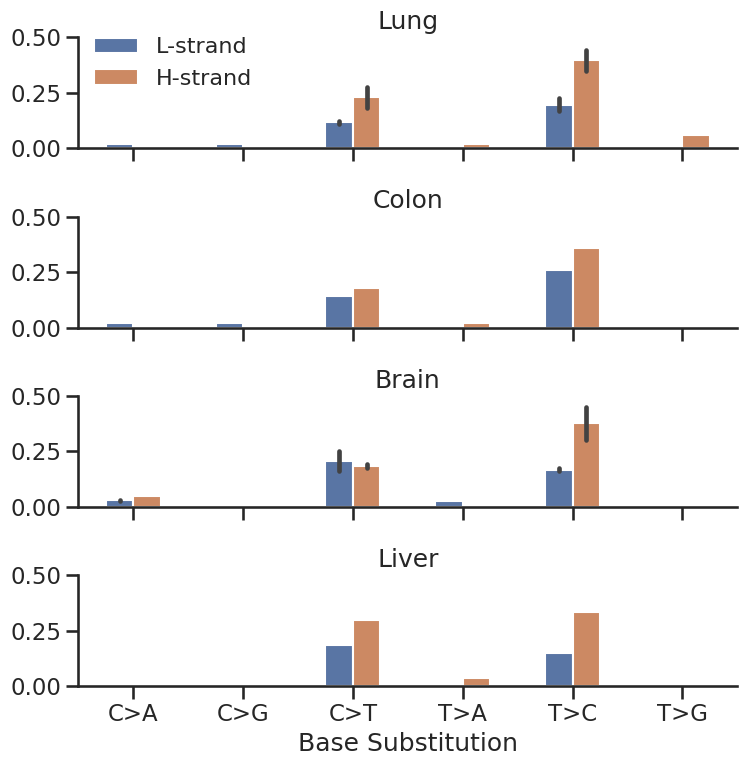

In [ ]:
collapsed_snv_df[['MT', 'POS', 'REF', 'ALT']] = collapsed_snv_df['ID'].str.split('-', expand=True)


collapsed_snv_df['nuc_change'] = collapsed_snv_df['REF'] + ">" + collapsed_snv_df['ALT']
collapsed_snv_df['rep_strand'] = np.where(collapsed_snv_df['REF'].isin(['C', 'T']), 'L-strand', 'H-strand')

conditions = [
    (collapsed_snv_df['nuc_change'] == 'G>A'),
    (collapsed_snv_df['nuc_change'] == 'G>T'),
    (collapsed_snv_df['nuc_change'] == 'G>C'),
    (collapsed_snv_df['nuc_change'] == 'A>T'),
    (collapsed_snv_df['nuc_change'] == 'A>C'),
    (collapsed_snv_df['nuc_change'] == 'A>G'),
]
values = ['C>T', 'C>A', 'C>G', 'T>A', 'T>G', 'T>C']

# Create a new column using np.select
collapsed_snv_df['nuc_change_revised'] = np.select(conditions, values, default='-')
collapsed_snv_df['nuc_change_revised'] = np.where(collapsed_snv_df['nuc_change_revised'] == '-', collapsed_snv_df['nuc_change'],collapsed_snv_df['nuc_change_revised'])


mut_sigs = collapsed_snv_df.groupby(['Donor', 'Tissue', 'rep_strand'])['nuc_change_revised'].value_counts().reset_index()
mut_sigs['Donor_Tissue'] = mut_sigs['Donor'] + "_" + mut_sigs['Tissue']

mut_sigs["prop"] = (
    mut_sigs["count"]
    / mut_sigs.groupby("Donor_Tissue")["count"].transform("sum")
)

mut_sigs = mut_sigs.sort_values('nuc_change_revised')

mut_sigs

sns.set_theme(style="ticks", context="talk", font_scale=1)

g = sns.catplot(
    data=mut_sigs,
    x="nuc_change_revised",
    y="prop",
    kind="bar",
    hue="rep_strand",
    row="Tissue",       
    height=2,        
    aspect=3,
    width=0.5,
    sharey=True,      
    sharex=True,
    legend=True
)

# Format axes
g.set_axis_labels('Base Substitution', '')
g.set_titles("{row_name}")
g.set(ylim=(0, 0.5))
sns.move_legend(g, "center right", bbox_to_anchor=(0.37,0.9), title="", fontsize=16) 
plt.tight_layout()
plt.savefig(f"plots/fig4-snv_base_subs.pdf", dpi=300)
plt.show()


In [ ]:
collapsed_snv_df[collapsed_snv_df['Status'] == 'Cfrm [LP]'][['ID', 'Donor', 'Tissue', 'Consequence', 'Symbol', 'Biotype', 'Disease', 'Status', 'AF', 'reps', 'rep_names']].sort_values(['AF'])

,ID,Donor,Tissue,Consequence,Symbol,Biotype,Disease,Status,AF,reps,rep_names
19,MT-13042-G-A,ST002,Lung,missense,MT-ND5,protein_coding,Optic neuropathy/ retinopathy/ LD,Cfrm [LP],0.00447,2,"ST002-1D_LUNG-pacbio-washu,ST002-1D_LUNG-ont-uwsc"


In [ ]:
## get df of region sizes
regions = pd.read_csv('/net/nwgc/vol1/home/czaka/tools/mitoscope/resources/annotations/GenomeLoci_MITOMAP.bed', sep='\t', names=['chrom', 'start', 'end', 'gene_name', 'gene_short_name', 'biotype', 'description'])
regions['size'] = regions['end'] - regions['start']
region_sizes = regions.groupby('biotype')['size'].sum().reset_index()

## exclude the small noncoding category // makes it hard when plotting and doing stat test
region_sizes = region_sizes[region_sizes['biotype'] != 'noncoding']

region_sizes

,biotype,size
0,control region,1121
2,protein coding,11382
3,rRNA,2511
4,tRNA,1486


In [ ]:
category_map = {
    'control region': 'intergenic',
    'noncoding': 'intergenic',
    'tRNA': 'non_coding_transcript_exon',
    'rRNA': 'non_coding_transcript_exon',
    'protein coding': 'protein coding'
}
region_sizes['for_conseq'] = region_sizes['biotype'].map(category_map)
regions_sizes_for_conseq = region_sizes.groupby('for_conseq')['size'].sum().reset_index()
regions_sizes_for_conseq

,for_conseq,size
0,intergenic,1121
1,non_coding_transcript_exon,3997
2,protein coding,11382


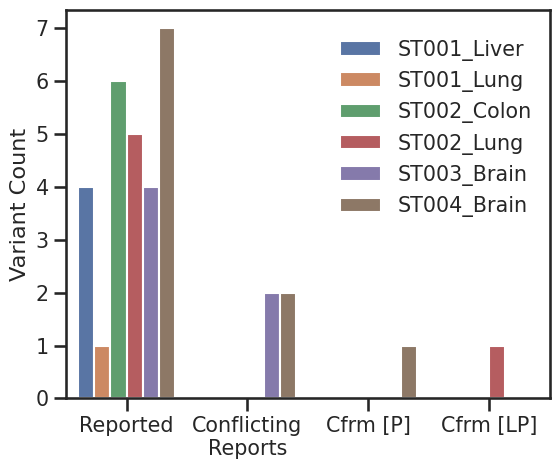

In [ ]:
csq_counts_disease = collapsed_snv_df.groupby(['Donor', 'Tissue'])['Status'].value_counts().reset_index()
csq_counts_disease['Donor_Tissue'] = csq_counts_disease['Donor'] + "_" + csq_counts_disease['Tissue']

sns.set_theme(style="ticks", context="talk", font_scale=0.9)

g = sns.catplot(
    data=csq_counts_disease[csq_counts_disease['Status'] != 'N/A'].sort_values('Status', ascending=False),
    x='Status',
    hue='Donor_Tissue',
    y='count',
    kind='bar',
    height=5,
    aspect=1.2,
    sharex=False,
    legend=True
)

sns.move_legend(g, loc='lower left', bbox_to_anchor=(0.45,0.5), title="")
sns.despine(top=False, right=False, left=False, bottom=False)
g.set_axis_labels('', 'Variant Count')
g.set_titles('{col_name}') # Set titles for each facet

x_positions = [0, 1, 2, 3]
custom_labels = ['Reported', 'Conflicting\nReports', 'Cfrm [P]', 'Cfrm [LP]' ]
plt.xticks(x_positions, custom_labels)

plt.savefig(f"plots/fig4-variant_disease_associations.pdf", dpi=300)
plt.show()


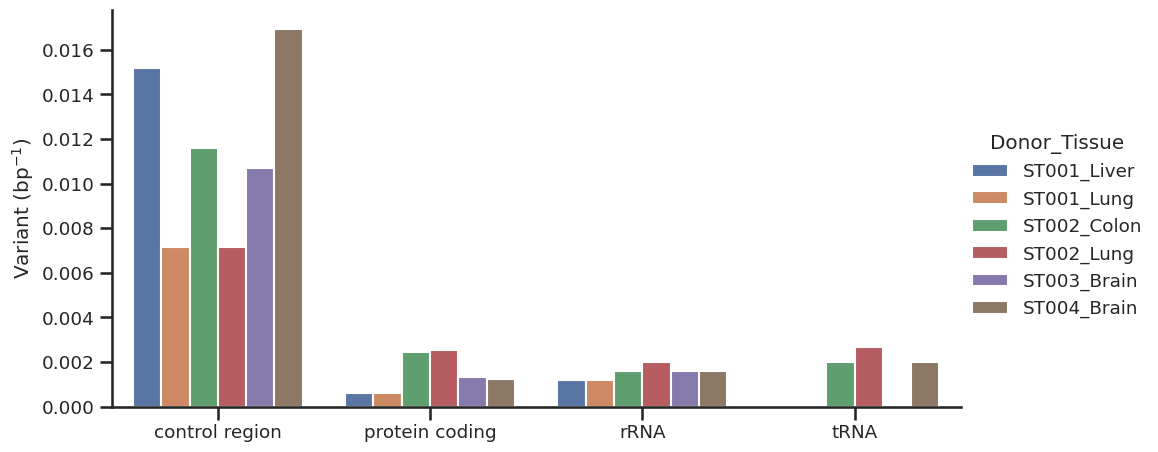

,m
Gene.Type,
control region,0.011448
protein coding,0.001464
rRNA,0.001527
tRNA,0.002243


In [ ]:
csq_counts_type = collapsed_snv_df.groupby(['Donor', 'Tissue'])['Gene.Type'].value_counts().reset_index()
csq_counts_type['Donor_Tissue'] = csq_counts_type['Donor'] + "_" + csq_counts_type['Tissue']

csq_counts_type = csq_counts_type[csq_counts_type['Gene.Type'] != 'noncoding']


csq_counts_type = pd.merge(csq_counts_type, region_sizes, left_on="Gene.Type", right_on="biotype", how="left")
csq_counts_type['per_bp_in_region'] = csq_counts_type['count'] / csq_counts_type['size']

sns.set_theme(style="ticks", context="talk", font_scale=0.8)

g = sns.catplot(
    data=csq_counts_type[csq_counts_type['Gene.Type'] != 'noncoding'],
    x='Gene.Type',
    hue='Donor_Tissue',
    y='per_bp_in_region',
    kind='bar',
    height=5,
    aspect=2,
    sharex=True,
)

g.set_axis_labels("", r'Variant (bp$^{-1}$)')
#plt.xticks(rotation=90)
plt.show()

csq_counts_type.groupby(['Gene.Type']).agg(m=('per_bp_in_region', 'mean'))

In [ ]:
variant_count_totals = csq_counts_type.groupby(['Donor_Tissue']).agg(total_variants=('count', 'sum'))
csq_counts_type = pd.merge(csq_counts_type, variant_count_totals, on="Donor_Tissue", how="left")
csq_counts_type['expected_variant_freq'] = csq_counts_type['size'] / 16569
csq_counts_type['obs_variant_freq'] = csq_counts_type['count'] / csq_counts_type['total_variants']
csq_counts_type['obs_to_exp_ratio'] = csq_counts_type['obs_variant_freq'] / csq_counts_type['expected_variant_freq']

csq_counts_type

,Donor,Tissue,Gene.Type,count,Donor_Tissue,biotype,size,for_conseq,per_bp_in_region,total_variants,expected_variant_freq,obs_variant_freq,obs_to_exp_ratio
0,ST001,Liver,control region,17,ST001_Liver,control region,1121,intergenic,0.015165,27,0.067656,0.629630,9.306274
1,ST001,Liver,protein coding,7,ST001_Liver,protein coding,11382,protein coding,0.000615,27,0.686946,0.259259,0.377409
2,ST001,Liver,rRNA,3,ST001_Liver,rRNA,2511,non_coding_transcript_exon,0.001195,27,0.151548,0.111111,0.733174
3,ST001,Lung,control region,8,ST001_Lung,control region,1121,intergenic,0.007136,18,0.067656,0.444444,6.569135
4,ST001,Lung,protein coding,7,ST001_Lung,protein coding,11382,protein coding,0.000615,18,0.686946,0.388889,0.566113
5,ST001,Lung,rRNA,3,ST001_Lung,rRNA,2511,non_coding_transcript_exon,0.001195,18,0.151548,0.166667,1.099761
6,ST002,Colon,protein coding,28,ST002_Colon,protein coding,11382,protein coding,0.002460,48,0.686946,0.583333,0.849170
7,ST002,Colon,control region,13,ST002_Colon,control region,1121,intergenic,0.011597,48,0.067656,0.270833,4.003066
8,ST002,Colon,rRNA,4,ST002_Colon,rRNA,2511,non_coding_transcript_exon,0.001593,48,0.151548,0.083333,0.549881
9,ST002,Colon,tRNA,3,ST002_Colon,tRNA,1486,non_coding_transcript_exon,0.002019,48,0.089686,0.062500,0.696879


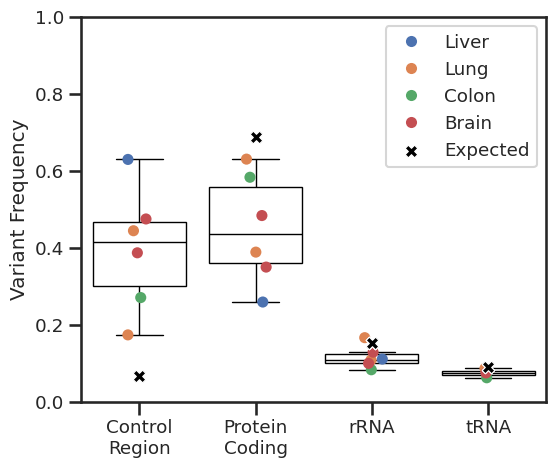

In [ ]:
sns.set_theme(style="ticks", context="talk", font_scale=0.8)

plt.figure(figsize=(6,5))

# Observed variants
sns.stripplot(
    data=csq_counts_type[csq_counts_type['Gene.Type'] != 'noncoding'],
    x="Gene.Type",
    y="obs_variant_freq",
    hue="Tissue",
    s=8,
    legend=True,
    zorder=20  # on top
)

# Expected variants (use different marker/color)
sns.scatterplot(
    data=csq_counts_type[csq_counts_type['Gene.Type'] != 'noncoding'],
    x="Gene.Type",
    y="expected_variant_freq",
    color='black',
    marker='X',
    s=80,
    label='Expected',
    zorder=30
)

# # Invisible boxplot for mean lines if you still want them
# sns.boxplot(
#     x="Gene.Type",
#     y="obs_variant_freq",
#     data=csq_counts_type[csq_counts_type['Gene.Type'] != 'noncoding'],
#     showmeans=True,
#     meanline=True,
#     meanprops={'color': 'k', 'ls': '-', 'lw': 2},
#     medianprops={'visible': False},
#     whiskerprops={'visible': False},
#     zorder=10,
#     showfliers=False,
#     showcaps=False,
#     showbox=False
# )

sns.boxplot(
    x="Gene.Type",
    y="obs_variant_freq",
    data=csq_counts_type[csq_counts_type['Gene.Type'] != 'noncoding'],
    color='white',
    linecolor='black',
    showfliers=False

)

# Custom x-axis labels
x_positions = [0, 1, 2, 3]
custom_labels = ['Control\nRegion', 'Protein\nCoding', 'rRNA', 'tRNA']
plt.xticks(x_positions, custom_labels)

plt.ylabel("Variant Frequency")
plt.xlabel("")

plt.legend()
plt.ylim(0,1)
plt.savefig(f"plots/fig4-variant_gene_types.pdf", dpi=300)
plt.show()


In [ ]:
csq_counts_type[csq_counts_type['Gene.Type'] != 'noncoding'][['Gene.Type', 'expected_variant_freq']].drop_duplicates()


,Gene.Type,expected_variant_freq
0,control region,0.067656
1,protein coding,0.686946
2,rRNA,0.151548
9,tRNA,0.089686


In [ ]:
csq_counts_type.groupby('Gene.Type')['obs_variant_freq'].mean()

Gene.Type
control region    0.396820
protein coding    0.449298
rRNA              0.116473
tRNA              0.074819
Name: obs_variant_freq, dtype: float64

In [ ]:
from scipy.stats import chisquare

obs = csq_counts_type.groupby("Gene.Type")["count"].sum()
mt_length = region_sizes['size'].sum()
expected = obs.sum() * pd.Series(region_sizes['size']) / mt_length

chi2, pval = chisquare(f_obs=obs, f_exp=expected)
print(chi2)
print(pval)


296.43808740591675
5.870187459691394e-64


In [ ]:
region_sizes

,biotype,size,for_conseq
0,control region,1121,intergenic
2,protein coding,11382,protein coding
3,rRNA,2511,non_coding_transcript_exon
4,tRNA,1486,non_coding_transcript_exon


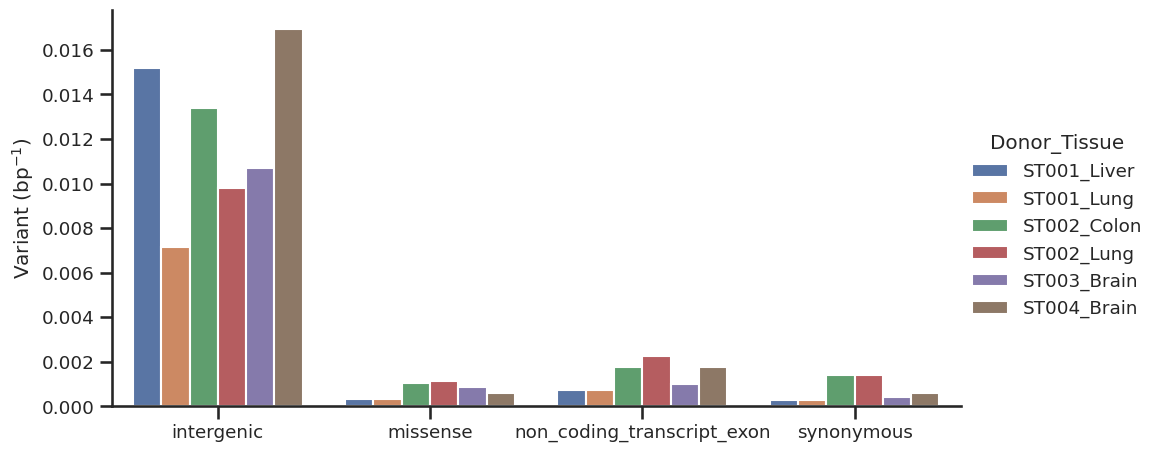

,m
Consequence,
intergenic,0.012191
missense,0.000732
non_coding_transcript_exon,0.001376
synonymous,0.000732


In [ ]:
csq_counts_conseq = collapsed_snv_df.groupby(['Donor', 'Tissue'])['Consequence'].value_counts().reset_index()
csq_counts_conseq['Donor_Tissue'] = csq_counts_conseq['Donor'] + "_" + csq_counts_conseq['Tissue']

category_map = {
    'intergenic': 'intergenic',
    'missense': 'protein coding',
    'synonymous': 'protein coding',
    'non_coding_transcript_exon': 'non_coding_transcript_exon',
}
csq_counts_conseq['mapped_category'] = csq_counts_conseq['Consequence'].map(category_map)
csq_counts_conseq = pd.merge(csq_counts_conseq, regions_sizes_for_conseq, left_on="mapped_category", right_on="for_conseq", how="left")
csq_counts_conseq['per_bp_in_region'] = csq_counts_conseq['count'] / csq_counts_conseq['size']
csq_counts_conseq


sns.set_theme(style="ticks", context="talk", font_scale=0.8)

g = sns.catplot(
    data=csq_counts_conseq,
    x='Consequence',
    hue='Donor_Tissue',
    y='per_bp_in_region',
  #  col='',
    kind='bar',
    height=5,
    aspect=2,
    sharex=False,
)

g.set_axis_labels('', r'Variant (bp$^{-1}$)')
g.set_titles('{col_name}') # Set titles for each facet
#plt.xticks(rotation=90)
#plt.yticks([0,5,10,15,20])
plt.show()

csq_counts_conseq.groupby(['Consequence']).agg(m=('per_bp_in_region', 'mean'))

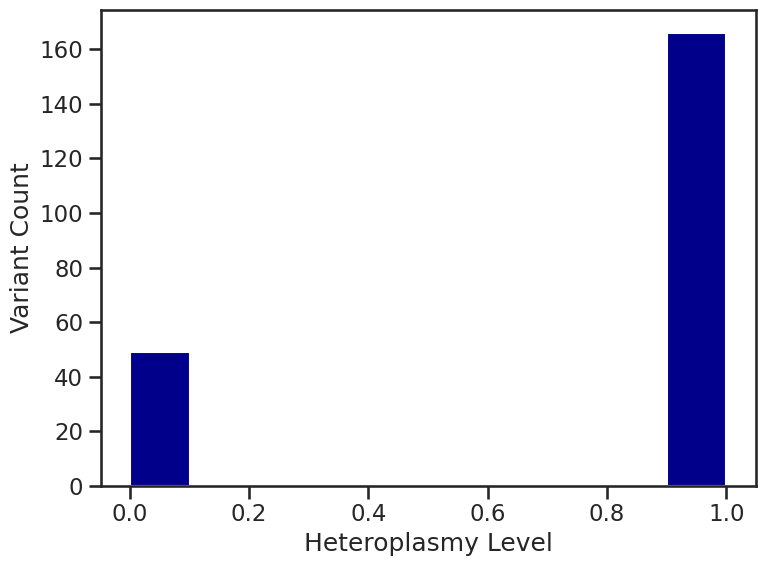

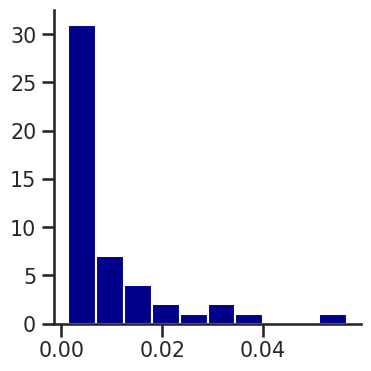

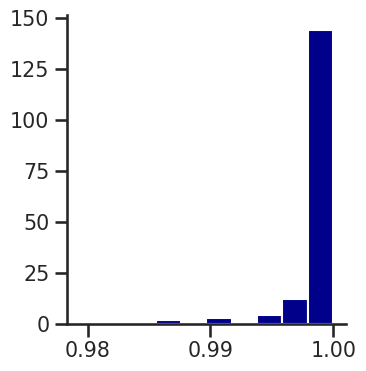

In [ ]:
sns.set_theme(style="ticks", context="talk", font_scale=1)

plt.figure(figsize=(8,6))
sns.histplot(
    data=collapsed_snv_df,
    x="AF",
  #  hue="heteroplasmy_category",     
   # palette="muted",
   color="darkblue",
    bins=10,
    alpha=1,
    legend=False
)
plt.ylabel("Variant Count")
plt.xlabel("Heteroplasmy Level")
plt.title("")
plt.tight_layout()
#plt.savefig(f"plots/fig4-heteroplasmy_levels.pdf", dpi=300)
plt.show()

sns.set_theme(style="ticks", context="talk", font_scale=0.9)
plt.figure(figsize=(4,4))
g = sns.histplot(
    data=collapsed_snv_df[collapsed_snv_df['heteroplasmy_category'] == 'hetero'],
    x="AF",
  #  hue="heteroplasmy_category",     
   # palette="muted",
   color="darkblue",
    bins=10,
    alpha=1,
    legend=False
)
ax = g.axes
sns.despine(ax=ax, left=False, right=True, bottom=False, top=True) 
#plt.yscale('log')
plt.ylabel("")
plt.xlabel("")
plt.title("")
plt.tight_layout()
#plt.savefig(f"plots/fig4-heteroplasmy_levels_left_side.pdf", dpi=300)
plt.show()

sns.set_theme(style="ticks", context="talk", font_scale=0.9)
plt.figure(figsize=(4,4))
g = sns.histplot(
    data=collapsed_snv_df[collapsed_snv_df['heteroplasmy_category'] == 'homo'],
    x="AF",
  #  hue="heteroplasmy_category",     
   # palette="muted",
   color="darkblue",
    bins=10,
    alpha=1,
    legend=False
)
ax = g.axes
sns.despine(ax=ax, left=False, right=True, bottom=False, top=True) 
#plt.yscale('log')
plt.ylabel("")
plt.xlabel("")
plt.title("")
plt.tight_layout()
#plt.savefig(f"plots/fig4-heteroplasmy_levels_right_side.pdf", dpi=300)
plt.show()

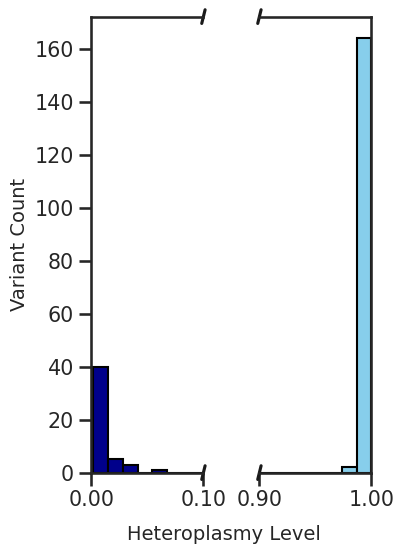

In [ ]:

# 1. Generate sample data with two distinct ranges
data_low = collapsed_snv_df[collapsed_snv_df['heteroplasmy_category'] == 'hetero']["AF"]
data_high = collapsed_snv_df[collapsed_snv_df['heteroplasmy_category'] == 'homo']["AF"]
data = np.concatenate([data_low, data_high])

# Define the break points
xlim1_end = 0.1
xlim2_start = 0.9

# 2. Create subplots with shared y-axis
fig, (ax, ax2) = plt.subplots(1, 2, sharey=True, figsize=(4, 6), facecolor='w', gridspec_kw={'width_ratios': [1, 1]})
fig.subplots_adjust(wspace=0.5) # adjust space between axes

# 3. Plot the histogram on both axes with different x-limits
bins = 75 # Use a consistent number of bins across both plots
ax.hist(data, bins=bins, color='darkblue', edgecolor='black')
ax2.hist(data, bins=bins, color='skyblue', edgecolor='black')

# Zoom-in / limit the view to different portions of the data
ax.set_xlim(0, xlim1_end) # Main data range
ax2.set_xlim(xlim2_start, 1) # Outlier range

# 4. Hide the spines between ax and ax2 to create the "break" appearance
ax.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax.yaxis.tick_left()
ax2.yaxis.tick_right()
ax2.tick_params(labelleft=False, right=False) # remove the left tick labels on the right plot

# 5. Add the "cut-out" diagonal lines for visual indication of the break
d = .015 # how big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
ax.plot((1-d, 1+d), (-d, +d), **kwargs)
ax.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
ax2.plot((-d, +d), (-d, +d), **kwargs)

ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax2.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax.set_ylabel("Variant Count", fontsize=14)
fig.supxlabel("    Heteroplasmy Level", y=0.001, fontsize=14)
fig.subplots_adjust(bottom=0.12, left=0.2)
plt.savefig(f"plots/fig4-heteroplasmy_levels_with_break.pdf", dpi=300)
plt.show()


In [ ]:
#collapsed_snv_df.sort_values('AF')['AF'].to_csv('look.csv')

conditions = [
    (collapsed_snv_df['AF'] > 0.95),
    (collapsed_snv_df['AF'] > 0.05) & (collapsed_snv_df['AF'] <= 0.1),
    (collapsed_snv_df['AF'] > 0.01) & (collapsed_snv_df['AF'] <= 0.05),
    (collapsed_snv_df['AF'] <= 0.01)
]
values = ['homo', 'het_mid', 'het_low', 'het_ultra_low']

# Create a new column using np.select
collapsed_snv_df['het_group'] = np.select(conditions, values, default='Unknown')

collapsed_snv_df['het_group'].value_counts()


het_group
homo             166
het_ultra_low     36
het_low           12
het_mid            1
Name: count, dtype: int64

In [ ]:
all_counts = collapsed_snv_df.groupby(['Donor', 'Tissue', 'Donor_Tissue']).size().reset_index(name="count")
sep_counts = collapsed_snv_df.groupby(['Donor', 'Tissue', 'Donor_Tissue', 'heteroplasmy_category']).size().reset_index(name="count")
homo_counts = sep_counts[sep_counts.heteroplasmy_category == 'homo']


['\n\nLiver', '\n\nLung', '\n\nLung', '\n\nColon', '\n\nBrain', '\n\nBrain']


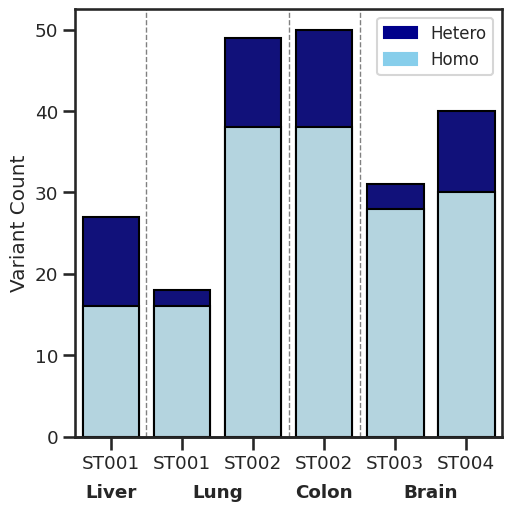

In [ ]:
sns.set_theme(style="ticks", context="talk", font_scale=0.8)

fig, ax = plt.subplots(layout='constrained', figsize=(5, 5))

sns.barplot(
    data=all_counts,
    x="Donor_Tissue",
    order=['ST001-Liver', 'ST001-Lung', 'ST002-Lung', 'ST002-Colon', 'ST003-Brain', 'ST004-Brain'],
    y="count",
    edgecolor='black',
    ax=ax,
    alpha=1,
    color="darkblue"
)
sns.barplot(
    data=homo_counts,
    x="Donor_Tissue",
    order=['ST001-Liver', 'ST001-Lung', 'ST002-Lung', 'ST002-Colon', 'ST003-Brain', 'ST004-Brain'],
    y="count",
    estimator=sum, 
    color="lightblue",
    alpha=1,
    edgecolor='black',
    ax=ax
)

# Get original tick labels
ticks = ax.get_xticklabels()
labels = [t.get_text() for t in ticks]
donors  = [l.split("-")[0] for l in labels]  
tissues = ['\n\n' + l.split("-")[1] for l in labels]

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(donors, rotation=0)
ax.set_ylabel("Variant Count")
ax.set_xlabel("")

sec = ax.secondary_xaxis(location=0)
sec.set_xticks([0,1.5,3,4.5], labels=['\n\nLiver', '\n\nLung', '\n\nColon', '\n\nBrain'])
sec.tick_params('x', length=0)

for tick in sec.get_xticklabels():
    tick.set_fontweight("bold")
    #tick.set_fontsize(14)

midpoints = [0.5,2.5,3.5]
for x in midpoints:
    ax.axvline(x=x,color="gray",linestyle="--",linewidth=1,alpha=1,zorder=0)

# add legend
top_bar = mpatches.Patch(color='darkblue', label='Hetero')
bottom_bar = mpatches.Patch(color='skyblue', label='Homo')
plt.legend(handles=[top_bar, bottom_bar], fontsize=12)
plt.savefig(f"plots/fig4-het_vs_hom_variant_counts.pdf", dpi=300)
print(tissues)

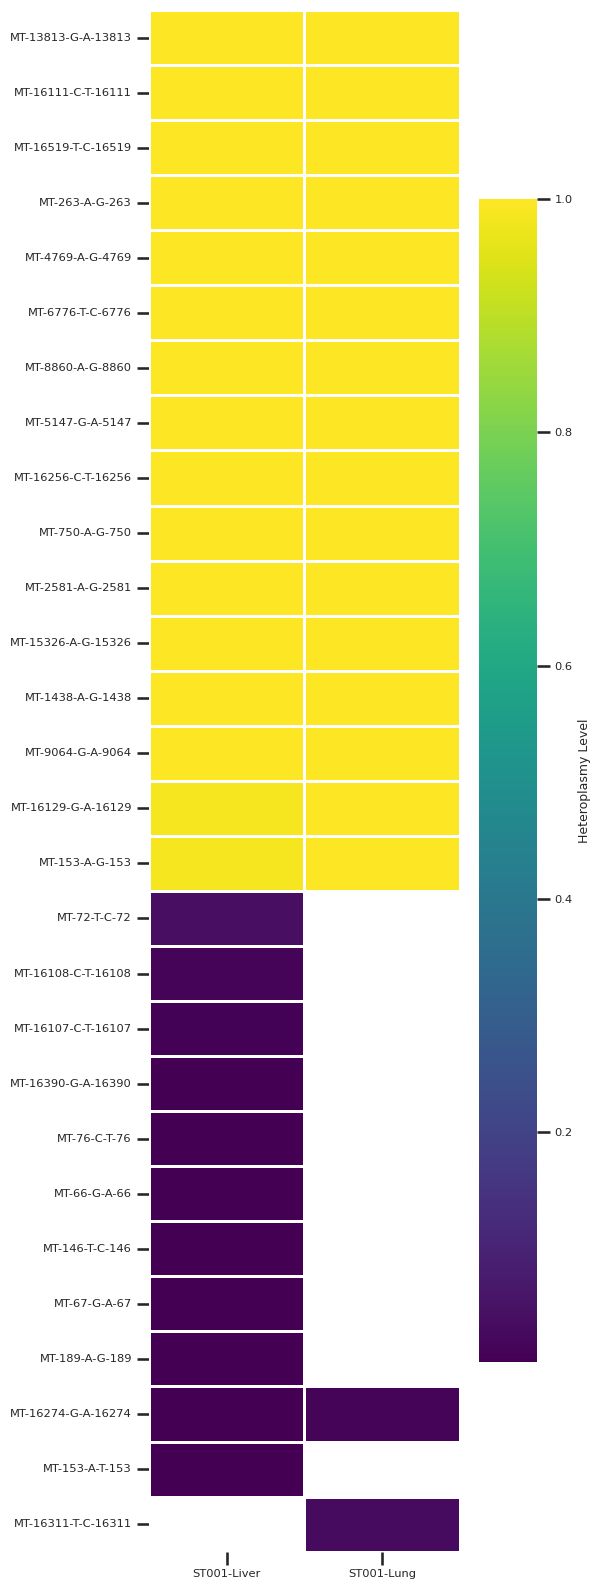

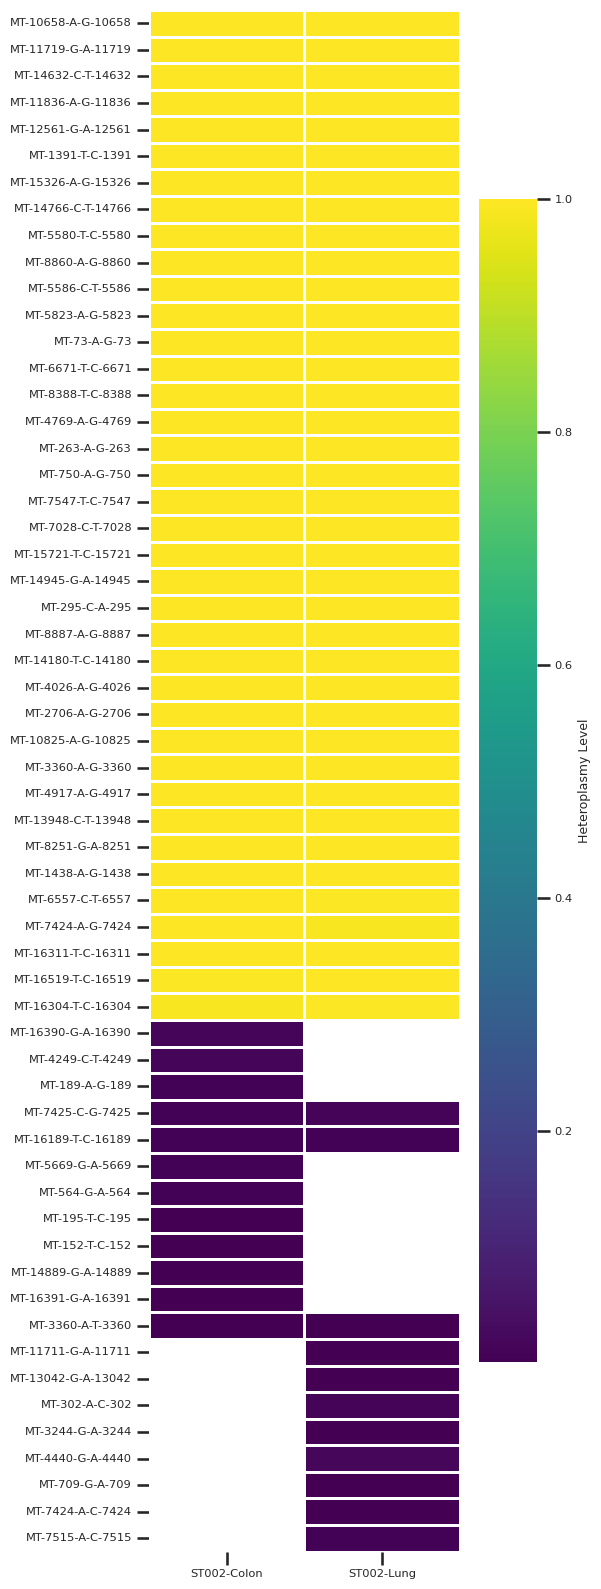

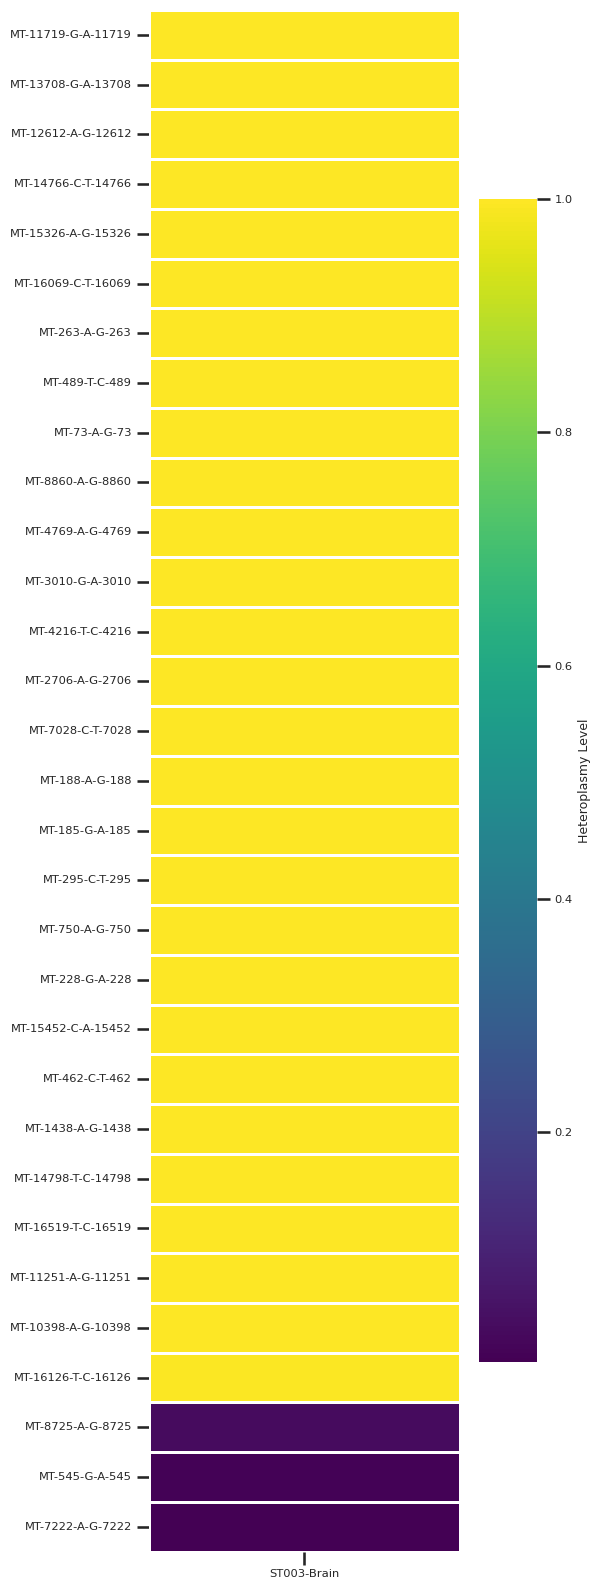

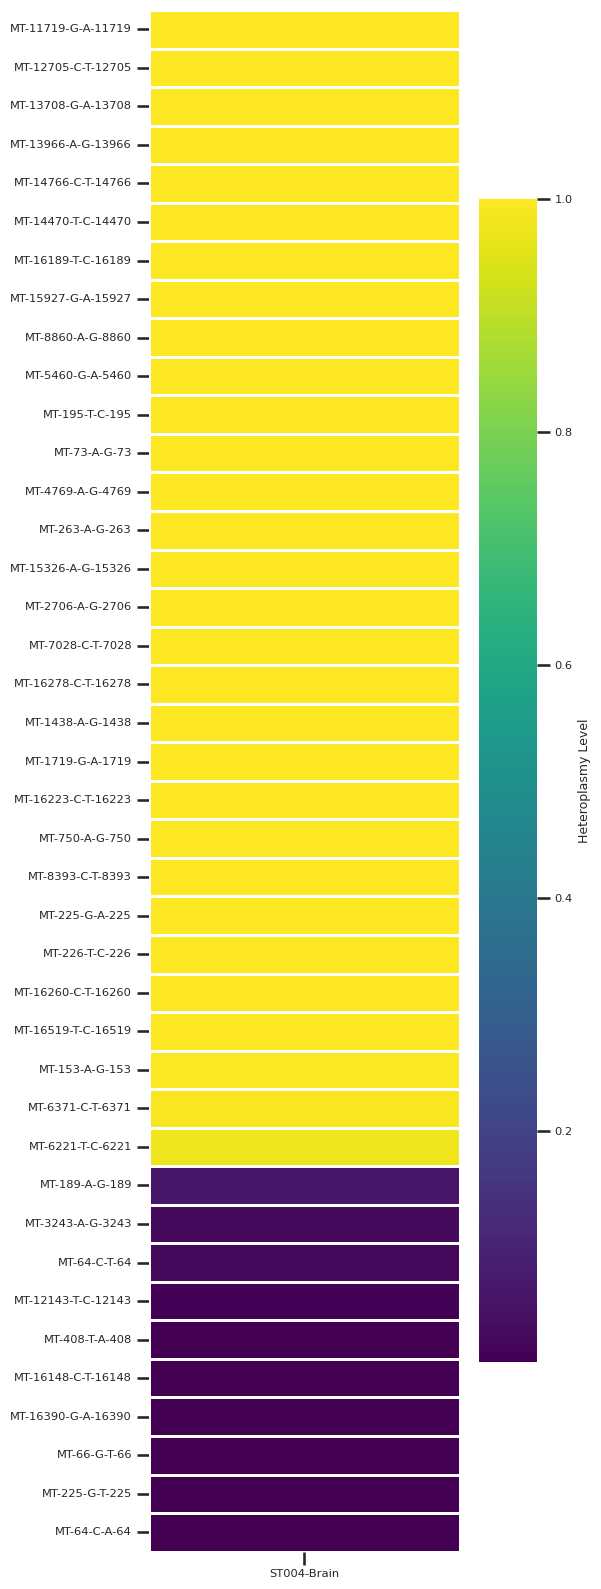

In [ ]:

sns.set_theme(style="ticks", context="talk", font_scale=0.5)

donors = ['ST001', 'ST002', 'ST003', 'ST004']
tissues = snv_df['Tissue'].unique()

for d in donors:

    heatmap_data = collapsed_snv_df[(collapsed_snv_df['Donor'] == d)].pivot(index=['Donor','Tissue'], columns=['ID','pos'], values='AF')

    ts = collapsed_snv_df[collapsed_snv_df['Donor'] == d]['Tissue'].unique()

    # Sort columns by highest average AF
    #heatmap_data = heatmap_data.sort_index(axis=1, level=[1,0], ascending=True)
    #column_order = heatmap_data.mean(axis=0).sort_values(ascending=False).index
    column_order = heatmap_data.sort_values(by=(d, ts[0]),axis=1, ascending=False).columns
    heatmap_data = heatmap_data[column_order]

    # Plot heatmap
    plt.figure(figsize=(6, 16))
    sns.heatmap(heatmap_data.T, cmap="viridis", linewidths=1,annot=False, cbar_kws={'label': 'Heteroplasmy Level'})
    plt.title('')
    plt.xlabel('')
    plt.ylabel('')
    plt.tight_layout()

    #plt.savefig(f'plots/benchmark_tissues.snv_heatmap.{d}.png', dpi=300)
    plt.show()


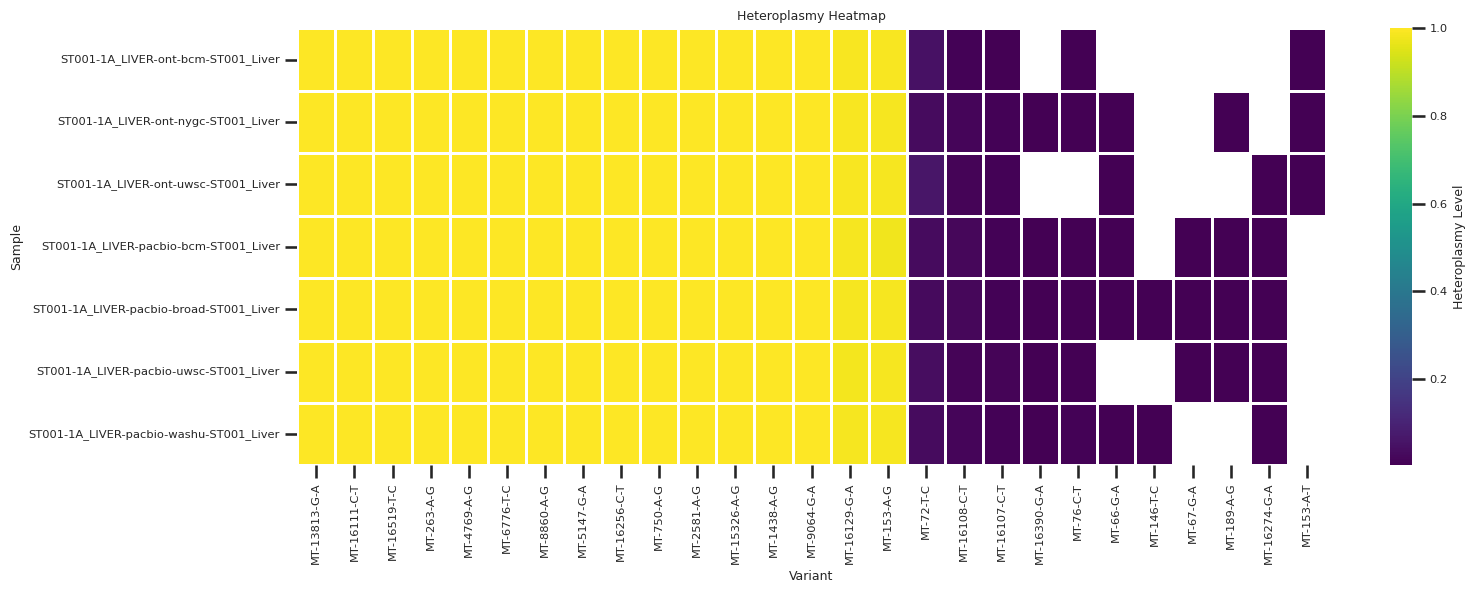

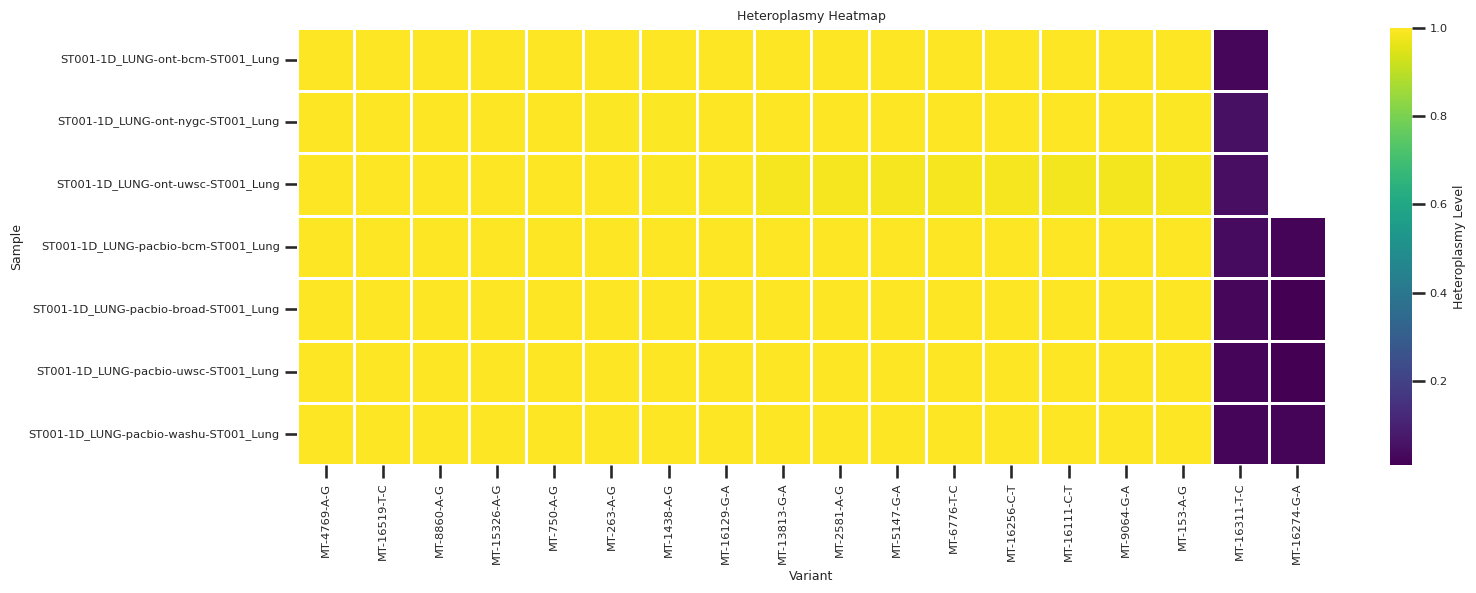

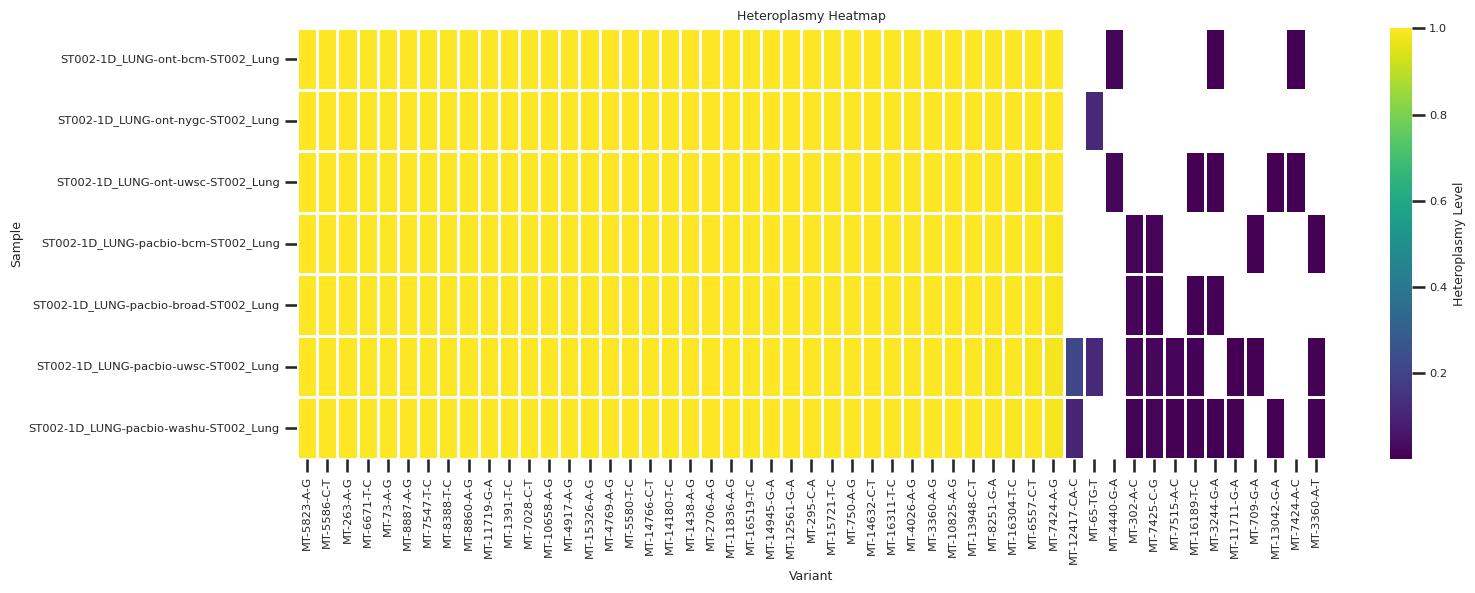

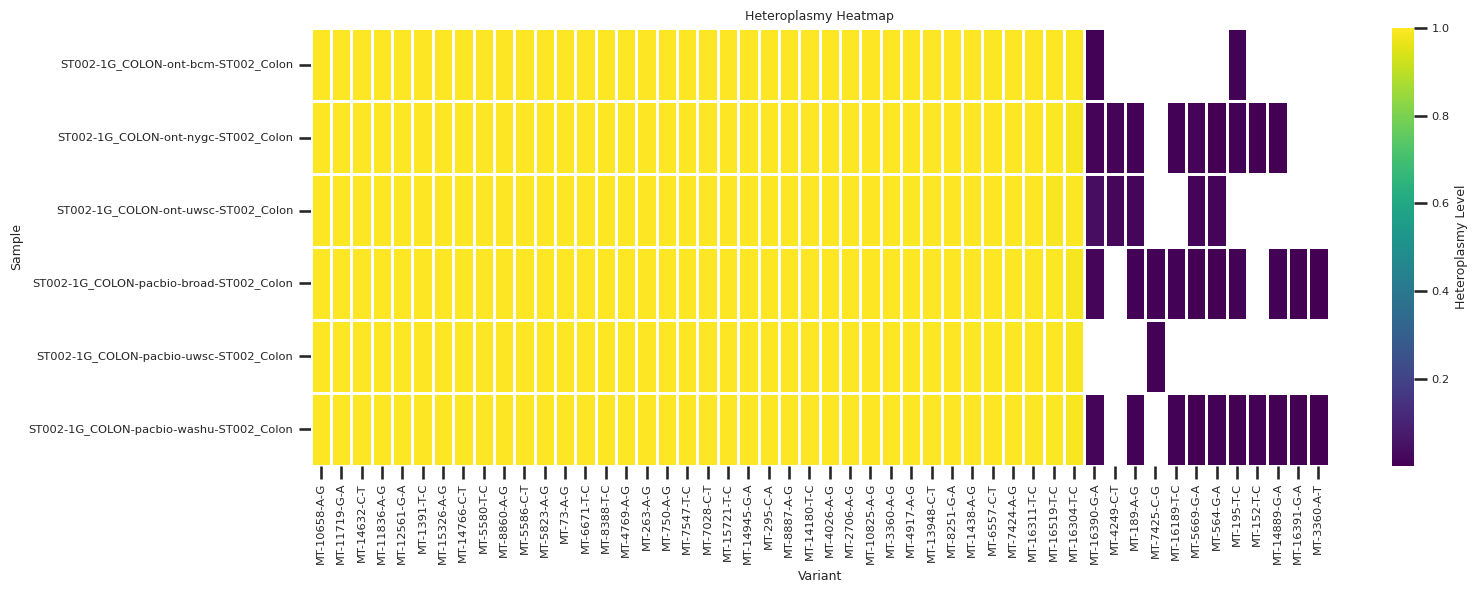

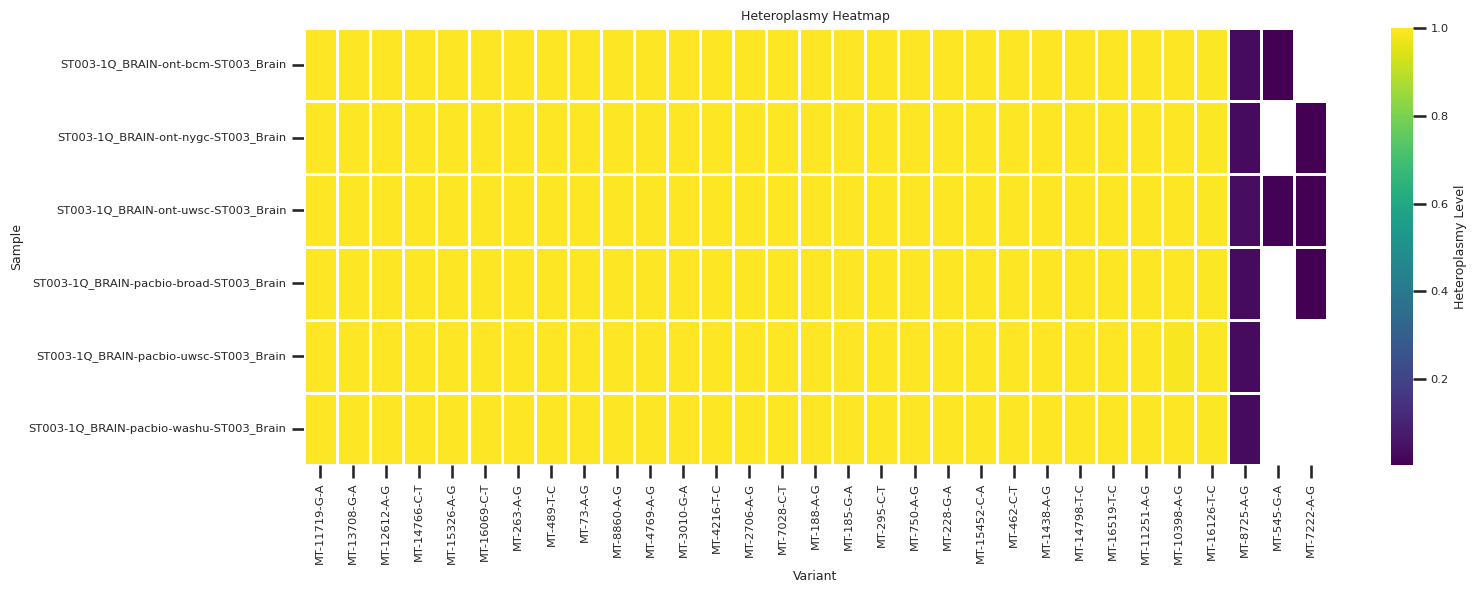

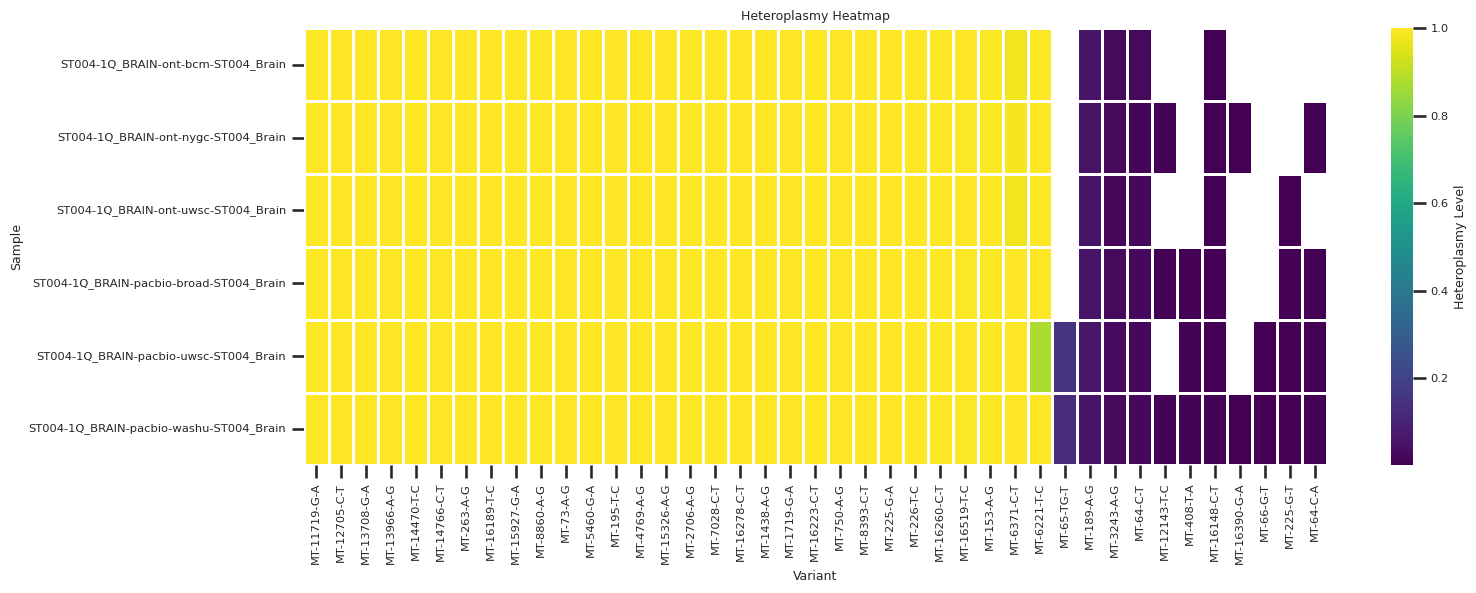

In [ ]:
sns.set_theme(style="ticks", context="talk", font_scale=0.5)

donors = ['ST001', 'ST002', 'ST003', 'ST004']
donor_tissues = snv_df['Donor_Tissue'].unique()

for d in donor_tissues:

    heatmap_data = high_conf_snv_df[high_conf_snv_df['Donor_Tissue'] == d].pivot(index=['Sample','Donor_Tissue'], columns='ID', values='AF')

    # Sort columns by highest average AF
    column_order = heatmap_data.mean(axis=0).sort_values(ascending=False).index
    heatmap_data = heatmap_data[column_order]

    # Plot heatmap
    plt.figure(figsize=(16, 6))
    sns.heatmap(heatmap_data, cmap="viridis", linewidths=1,annot=False, cbar_kws={'label': 'Heteroplasmy Level'})
    plt.title('Heteroplasmy Heatmap')
    plt.xlabel('Variant')
    plt.ylabel('Sample')
    plt.tight_layout()
    plt.show()



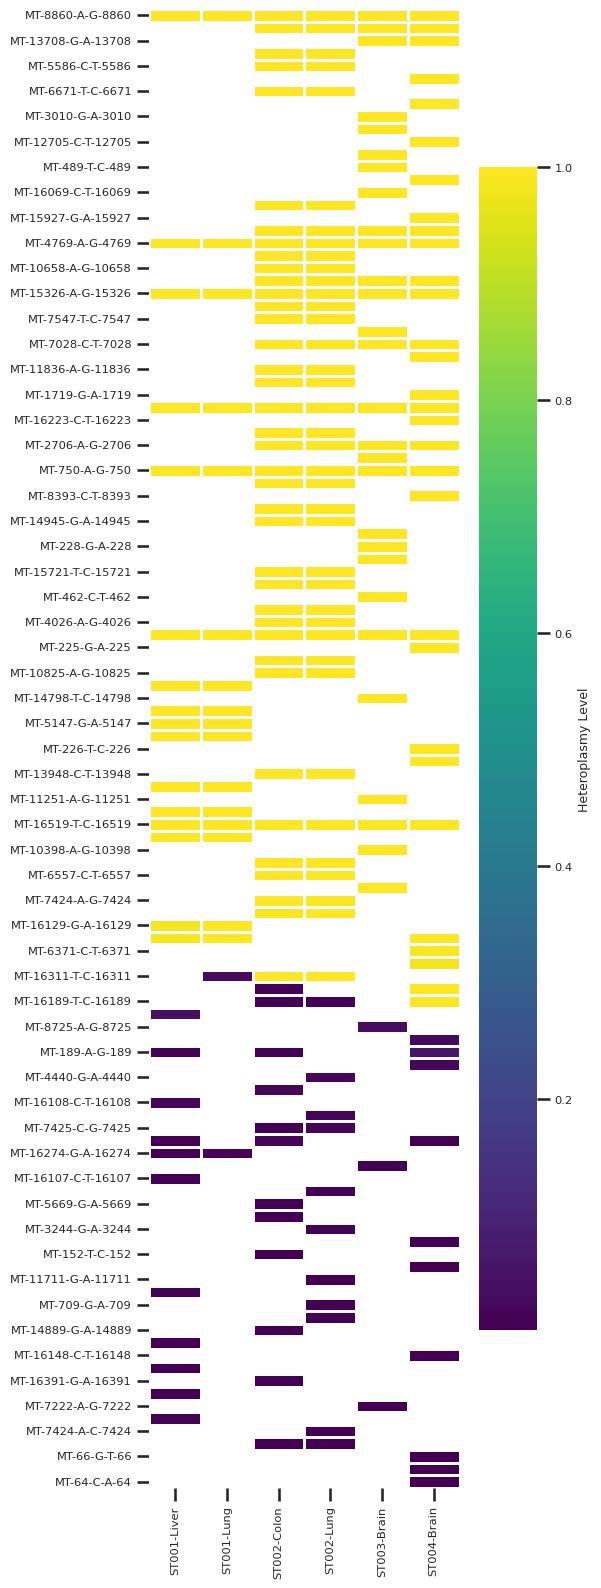

In [ ]:
sns.set_theme(style="ticks", context="talk", font_scale=0.5)

donors = ['ST001', 'ST002', 'ST003', 'ST004']
tissues = snv_df['Tissue'].unique()

heatmap_data = collapsed_snv_df.pivot(index=['Donor','Tissue'], columns=['ID','pos'], values='AF')
ts = collapsed_snv_df[collapsed_snv_df['Donor'] == d]['Tissue'].unique()

# Sort columns by highest average AF
#heatmap_data = heatmap_data.sort_index(axis=1, level=[1,0], ascending=True)
column_order = heatmap_data.mean(axis=0).sort_values(ascending=False).index
#column_order = heatmap_data.sort_values(by=(d, ts[0]),axis=1, ascending=False).columns
heatmap_data = heatmap_data[column_order]

# Plot heatmap
plt.figure(figsize=(6, 16))
sns.heatmap(heatmap_data.T, cmap="viridis", linewidths=1,annot=False, cbar_kws={'label': 'Heteroplasmy Level'})
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()

plt.savefig(f'plots/benchmark_tissues.snv_heatmap.pdf', dpi=300)
plt.show()



In [ ]:

collapsed_snv_df.pivot(index=['Donor','Tissue'], columns=['ID','pos'], values='AF').T.to_csv('tables/high_confidence_snvs_benchmarking_tissues.csv')


/net/wei/vol1/home/czaka/miniforge3/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/net/wei/vol1/home/czaka/miniforge3/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["l

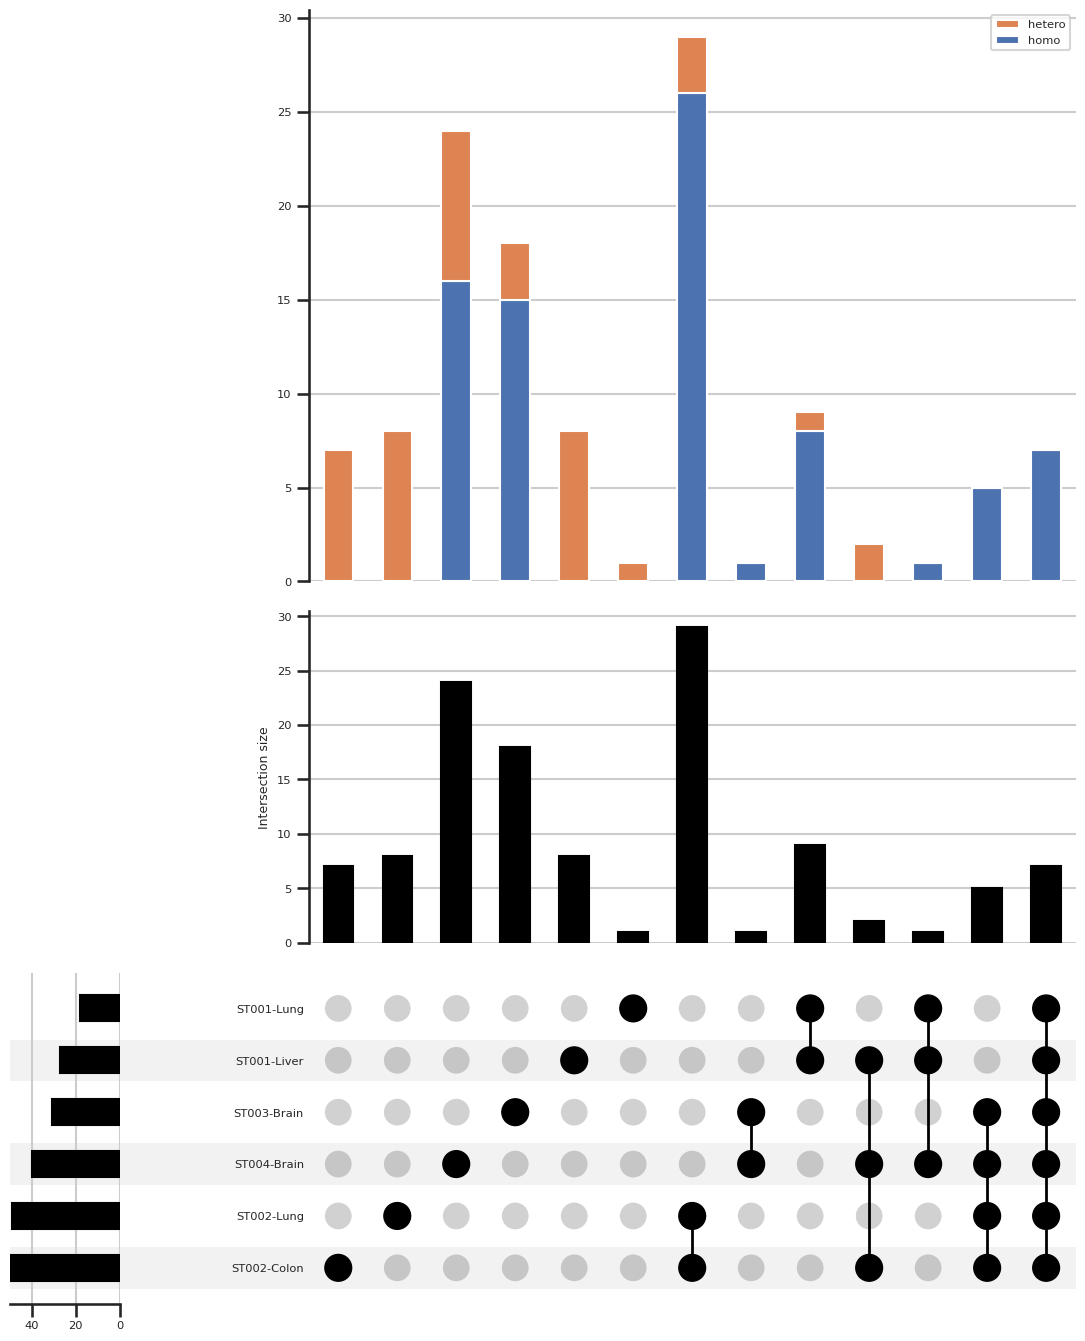

In [ ]:
import upsetplot

new_df = collapsed_snv_df.groupby(['ID', 'heteroplasmy_category'])['Donor_Tissue'].agg(','.join).reset_index()
new_df

upset_df = upsetplot.from_memberships(new_df.Donor_Tissue.str.split(","), data=new_df)

fig = plt.figure(figsize=(12, 6))
t = upsetplot.UpSet(upset_df, element_size=55)
t.add_stacked_bars(
    by="heteroplasmy_category", title="", elements=10
)
t.plot(fig=fig)
plt.show()

fig.savefig("my_upset_plot_object.png", dpi=300)

/net/wei/vol1/home/czaka/miniforge3/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/net/wei/vol1/home/czaka/miniforge3/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/net/wei/vol1/home/czaka/miniforge3/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The beha

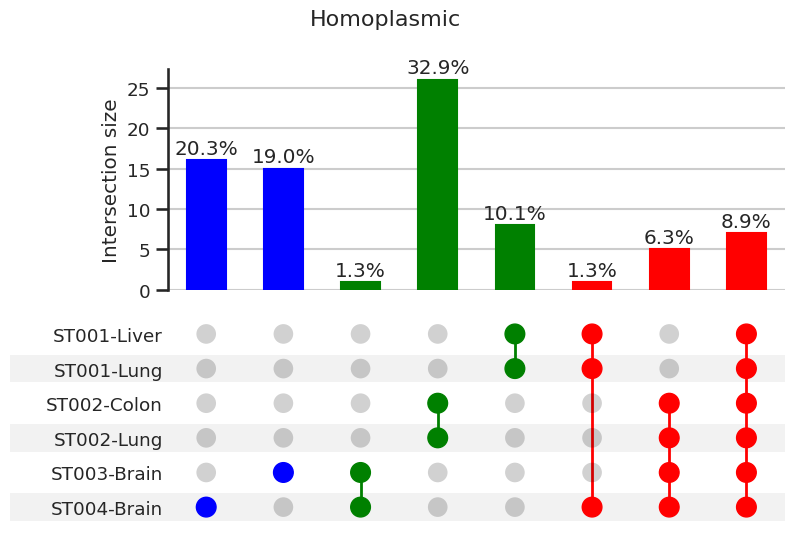

/net/wei/vol1/home/czaka/miniforge3/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/net/wei/vol1/home/czaka/miniforge3/lib/python3.10/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are sett

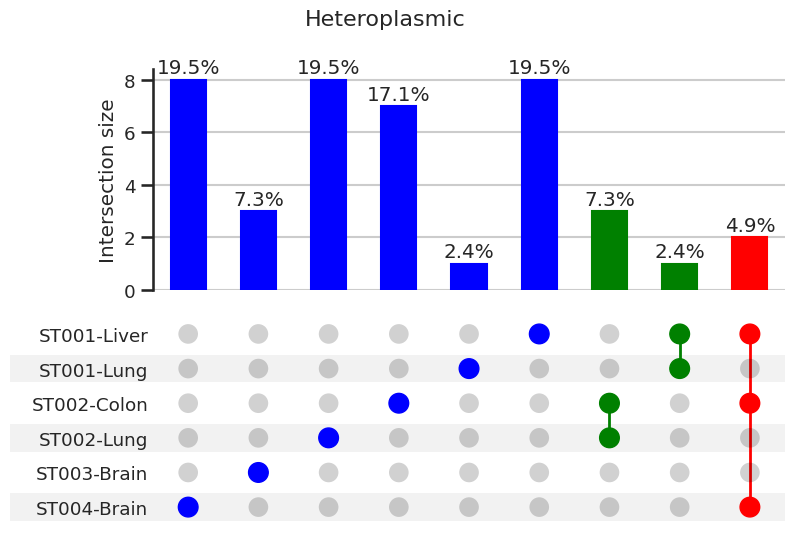

In [ ]:
from upsetplot import generate_counts, plot
import upsetplot

new_df = collapsed_snv_df.groupby(['ID', 'heteroplasmy_category'])['Donor_Tissue'].agg(','.join).reset_index()

upset_df_homo = upsetplot.from_memberships(new_df[new_df['heteroplasmy_category'] == 'homo'].Donor_Tissue.str.split(","), data=new_df[new_df['heteroplasmy_category'] == 'homo'])
upset_df_hetero = upsetplot.from_memberships(new_df[new_df['heteroplasmy_category'] == 'hetero'].Donor_Tissue.str.split(","), data=new_df[new_df['heteroplasmy_category'] == 'hetero'])

sns.set_theme(style="ticks", context="talk", font_scale=0.8)

fig = plt.figure(figsize=(10,6))
t = upsetplot.UpSet(upset_df_homo, element_size=None, sort_categories_by="-input", sort_by="degree", show_percentages=True, totals_plot_elements=0)
t.style_subsets(min_degree=1, facecolor="blue", )
t.style_subsets(min_degree=2, facecolor="green")
t.style_subsets(min_degree=3, facecolor="red", )
t.plot(fig)
plt.suptitle("Homoplasmic", size=16)
fig.savefig("plots/fig4-upset_plot_homo.pdf", dpi=300)
plt.show()

# fig = plt.figure(figsize=(10,6))
# plot(upset_df_hetero, fig=fig, element_size=None, sort_categories_by="-input", sort_by="degree", show_percentages=True, totals_plot_elements=0)
# fig.savefig("plots/fig4-upset_plot_hetero.pdf", dpi=300)
# plt.show()

fig = plt.figure(figsize=(10,6))
t = upsetplot.UpSet(upset_df_hetero, element_size=None, sort_categories_by="-input", sort_by="degree", show_percentages=True, totals_plot_elements=0)
t.style_subsets(min_degree=1, facecolor="blue")
t.style_subsets(min_degree=2, facecolor="green")
t.style_subsets(min_degree=3, facecolor="red")
t.plot(fig)
plt.suptitle("Heteroplasmic", size=16)
fig.savefig("plots/fig4-upset_plot_hetero.pdf", dpi=300)
plt.show()


In [ ]:
## pileup verification for discordant positions (8860,4769)
positions = [3243, 13042]
indir="/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/analysis/pileup_bases/benchmark"

comb_x = pd.DataFrame()
for s in df['Sample'].unique():
    for p in positions:
        x = pd.read_csv(f'{indir}/{s}.{p}.base_comp.txt', sep=" ", names=['freq', 'base'])
        x['sample'] = s
        x['pos'] = p
        comb_x = pd.concat([comb_x, x])

sr_data = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mutect2/smaht/illumina/benchmark/samples.csv')
for s in sr_data['sample_id'].unique():
    for p in positions:
        x = pd.read_csv(f'{indir}/{s}.{p}.base_comp.txt', sep=" ", names=['freq', 'base'])
        x['sample'] = s
        x['pos'] = p
        comb_x = pd.concat([comb_x, x])
    
comb_x['base'] = comb_x['base'].str.upper()
#comb_x = comb_x[~comb_x['base'].isin(['*'])]

comb_x_collapsed = comb_x.groupby(['sample', 'pos', 'base'])['freq'].sum().reset_index()
comb_x_collapsed['prop'] = comb_x_collapsed['freq'] / comb_x_collapsed.groupby(['sample', 'pos'])['freq'].transform('sum')
comb_x_collapsed[['donor', 'tissue', 'tech', 'center']] = comb_x_collapsed['sample'].str.split('-', expand=True)
comb_x_collapsed['Donor_Tissue'] = comb_x_collapsed['donor'] + "-" + comb_x_collapsed['tissue']
comb_x_collapsed

idx_levels = {col: comb_x_collapsed[col].unique() for col in ['sample', 'pos', 'base']}
new_idx = pd.MultiIndex.from_product(idx_levels.values(), names=idx_levels.keys())
comb_x_collapsed = comb_x_collapsed.set_index(list(idx_levels)).reindex(new_idx, fill_value=0).reset_index()
comb_x_collapsed[['donor', 'tissue', 'tech', 'center']] = comb_x_collapsed['sample'].str.split('-', expand=True)
comb_x_collapsed['Donor_Tissue'] = comb_x_collapsed['donor'] + "-" + comb_x_collapsed['tissue']
comb_x_collapsed


,sample,pos,base,freq,prop,donor,tissue,tech,center,Donor_Tissue
0,ST001-1A_LIVER-ont-bcm,3243,*,4,0.000410,ST001,1A_LIVER,ont,bcm,ST001-1A_LIVER
1,ST001-1A_LIVER-ont-bcm,3243,A,9759,0.999181,ST001,1A_LIVER,ont,bcm,ST001-1A_LIVER
2,ST001-1A_LIVER-ont-bcm,3243,C,1,0.000102,ST001,1A_LIVER,ont,bcm,ST001-1A_LIVER
3,ST001-1A_LIVER-ont-bcm,3243,G,3,0.000307,ST001,1A_LIVER,ont,bcm,ST001-1A_LIVER
4,ST001-1A_LIVER-ont-bcm,3243,T,0,0.000000,ST001,1A_LIVER,ont,bcm,ST001-1A_LIVER
...,...,...,...,...,...,...,...,...,...,...
485,ST004-1Q_BRAIN-pacbio-washu,13042,*,39,0.002276,ST004,1Q_BRAIN,pacbio,washu,ST004-1Q_BRAIN
486,ST004-1Q_BRAIN-pacbio-washu,13042,A,3,0.000175,ST004,1Q_BRAIN,pacbio,washu,ST004-1Q_BRAIN
487,ST004-1Q_BRAIN-pacbio-washu,13042,C,1,0.000058,ST004,1Q_BRAIN,pacbio,washu,ST004-1Q_BRAIN
488,ST004-1Q_BRAIN-pacbio-washu,13042,G,17089,0.997432,ST004,1Q_BRAIN,pacbio,washu,ST004-1Q_BRAIN


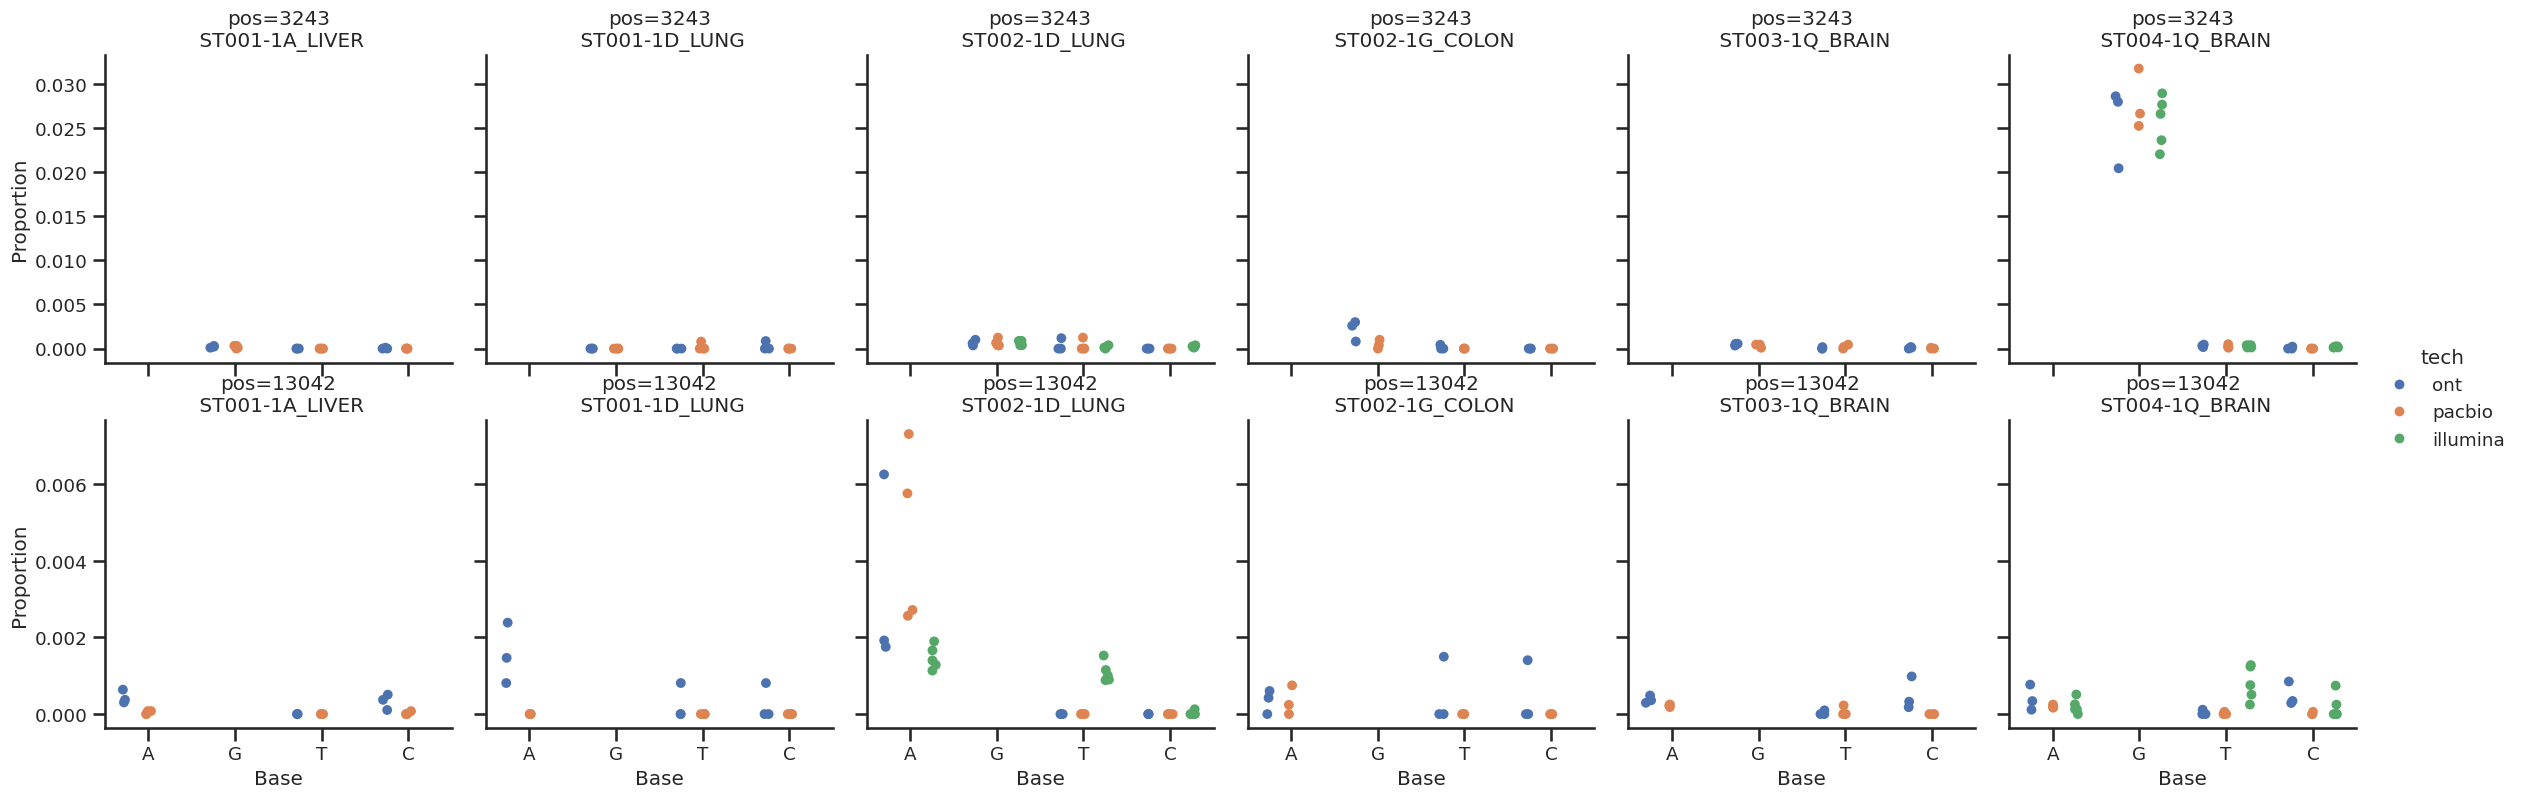

In [ ]:
sns.set_theme(style="ticks", context="talk", font_scale=0.8)

# Use sns.catplot() instead of sns.barplot()
g = sns.catplot(
    data=comb_x_collapsed[(comb_x_collapsed['prop'] < 0.95) & (comb_x_collapsed['base'] != '*')],
    x='base',
    order=['A', 'G', 'T', 'C'],
    y='prop',
    hue='tech',
    row='pos',
    col='Donor_Tissue',
    kind='strip',
    height=4,
    aspect=1,
    sharey='row',
    dodge=True,
    s=50
)

g.set_axis_labels("Base", "Proportion")
#for ax in g.axes.flat:
   # ax.set_yscale('log')
   # ax.set_ylim(0,0.01)
g.set_titles("pos={row_name}\n {col_name}")
plt.savefig(f"plots/supplementary/pileup_freqs_pathogenic_variants.pdf", dpi=300)
plt.show()
